<center><image src="https://drive.google.com/uc?id=1n3G4TdK_u6PQHcLrxB_A0HijNdigXmUH">

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Домашнее задание. Сегментация изображений</b></h3>


В этом задании вам предстоит решить задачу сегментации медицинских снимков. Домашнее задание можно разделить на следующие части:

* Построй свой первый бейзлайн! [6]
  * BCE Loss [2]
  * SegNet [2]
  * Train [1]
  * Test [1]
* Мир других лоссов! [2]
  * Dice Loss [1]
  * Focal Loss [1]
  * BONUS: лосс из статьи [5]
* Новая модель! [2]
  * UNet [2]


**Максимальный балл:** 10 баллов.

Также для студентов желающих еще более углубиться в задачу предлагается решить бонусное задание, которое даст дополнительные 5 баллов. BONUS задание необязательное.


In [1]:
import random
import torch
import numpy as np
import os

# Шаг 1. Загрузка и подготовка данных

1. Для начала мы скачаем датасет: [ADDI project](https://www.fc.up.pt/addi/ph2%20database.html).
2. Разархивируем .rar файл.
3. Обратите внимание, что папка  `PH2 Dataset images` должна лежать там же где и ipynb notebook.

Это фотографии двух типов **поражений кожи:** меланома и родинки.
В данном задании мы не будем заниматься их классификацией, а будем **сегментировать** их.

In [2]:
import warnings
warnings.filterwarnings(action='ignore')

In [3]:
# !gdown 1T_RPkPP0jeWwK8L1UrmBw8V30eD7v6Ql
# get_ipython().system_raw("unrar x PH2Dataset.rar")

In [4]:
import gdown

os.makedirs('content', exist_ok=True)
os.makedirs('models', exist_ok=True)

In [5]:
file_id = '1T_RPkPP0jeWwK8L1UrmBw8V30eD7v6Ql'
output = 'content/PH2Dataset.rar'

if not os.path.exists(output):
    gdown.download(id=file_id, output=output, quiet=True)

In [6]:
import patoolib

if os.path.exists(output):
    extract_path = 'content/PH2Dataset'
    patoolib.extract_archive(output, outdir=extract_path)

INFO patool: Extracting content/PH2Dataset.rar ...
INFO patool: could not find a 'file' executable, falling back to guess mime type by file extension
INFO patool: running "C:\Program Files\WinRAR\rar.EXE" x -kb -or -- c:\Projects\ds-stepik\deep_learning_1_2026\08_semantic_segmentation\content\PH2Dataset.rar
INFO patool: ... content/PH2Dataset.rar extracted to `content/PH2Dataset'.


Стуктура датасета у нас следующая:

    IMD_002/
        IMD002_Dermoscopic_Image/
            IMD002.bmp
        IMD002_lesion/
            IMD002_lesion.bmp
        IMD002_roi/
            ...
    IMD_003/
        ...
        ...

 Здесь `X.bmp` — изображение, которое нужно сегментировать, `X_lesion.bmp` — результат сегментации.

Для загрузки датасета можно использовать skimage: [`skimage.io.imread()`](https://scikit-image.org/docs/dev/api/skimage.io.html)

In [7]:
images = []
lesions = []

from skimage.io import imread

root = extract_path + '/PH2Dataset'

for root, dirs, files in os.walk(os.path.join(root, 'PH2 Dataset images')):
    if root.endswith('_Dermoscopic_Image'):
        images.append(imread(os.path.join(root, files[0])))
    if root.endswith('_lesion'):
        lesions.append(imread(os.path.join(root, files[0])))

Изображения имеют разные размеры. Давайте изменим их размер на $256\times256 $ пикселей. Для изменения размера изображений можно использовать [`skimage.transform.resize()`](https://scikit-image.org/docs/dev/api/skimage.transform.html#skimage.transform.resize).
Эта функция также автоматически нормализует изображения в диапазоне $[0,1]$.


In [8]:
from skimage.transform import resize

size = (256, 256)
X = [resize(x, size, mode='constant', anti_aliasing=True,) for x in images]
Y = [resize(y, size, mode='constant', anti_aliasing=False) > 0.5 for y in lesions]

In [9]:
X = np.array(X, np.float32)
Y = np.array(Y, np.float32)
print(f'Loaded {len(X)} images')

Loaded 200 images


Чтобы убедиться, что все корректно, мы нарисуем несколько изображений

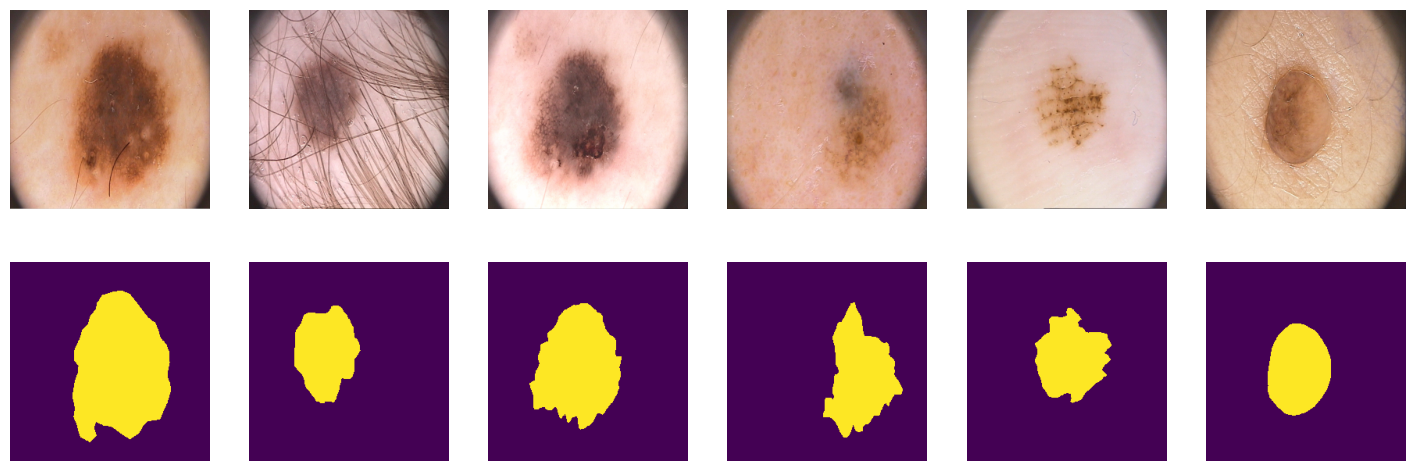

In [10]:
import matplotlib.pyplot as plt
from IPython.display import clear_output

plt.figure(figsize=(18, 6))
for i in range(6):
    plt.subplot(2, 6, i+1)
    plt.axis("off")
    plt.imshow(X[i])

    plt.subplot(2, 6, i+7)
    plt.axis("off")
    plt.imshow(Y[i])
    
plt.show();

Разделим наши 200 картинок на 100/50/50
 для обучения, валидации и теста соответственно

In [11]:
ix = np.random.choice(len(X), len(X), False)
tr, val, ts = np.split(ix, [100, 150])

In [12]:
print(len(tr), len(val), len(ts))

100 50 50


## PyTorch DataLoader

In [13]:
from torch.utils.data import DataLoader

_pin = torch.cuda.is_available()

batch_size = 25
train_dataloader = DataLoader(
    list(zip(np.rollaxis(X[tr], 3, 1), 
             Y[tr, np.newaxis])),
             batch_size=batch_size, 
             shuffle=True,
             pin_memory=_pin
             )

valid_dataloader = DataLoader(
    list(zip(np.rollaxis(X[val], 3, 1), 
             Y[val, np.newaxis])),
             batch_size=batch_size, 
             shuffle=False,
             pin_memory=_pin
             )

test_dataloader = DataLoader(
    list(zip(np.rollaxis(X[ts], 3, 1), 
             Y[ts, np.newaxis])),
             shuffle=False,
             pin_memory=_pin
             )

loaders = {
    'train': train_dataloader,
    'val': valid_dataloader,
    'test': test_dataloader
}

In [14]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


# Шаг 2. Метрика качества модели

## IoU (intersection over union)

В данном разделе предлагается использовать следующую метрику для оценки качества:

$I o U=\frac{\text {target } \cap \text { prediction }}{\text {target } \cup{prediction }}$

Пересечение (A ∩ B) состоит из пикселей, найденных как в маске предсказания, так и в основной маске истины, тогда как объединение (A ∪ B) просто состоит из всех пикселей, найденных либо в маске предсказания, либо в целевой маске.


Что будет являться пересением и объединением в задаче сегментации?

Давайте разберем следующий пример:



In [15]:
# !pip install torchmetrics

In [16]:
from torchmetrics import JaccardIndex

iou_score = JaccardIndex(threshold=0.5, task="binary", average='none').to(device)

# Задания: Построй свой первый бейзлайн!

Итак, загрузка файлов, код датасета и даталоадера написана за вас. Метрика IoU написана за вас! Вам остается написать лосс, модель и функции обучения и теста модели.

* Построй свой первый бейзлайн! [6]
  * BCE Loss [2]
  * SegNet [2]
  * Train [1]
  * Test [1]

## Шаг 3. Loss функция - BCE [2 балла]

Популярным лоссом для бинарной сегментации является *бинарная кросс-энтропия*, которая задается следующим образом:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right] \space [1]$$

где $y$ это  таргет желаемого результата и $\hat y$ является выходом модели. $\sigma$ - это [*логистическая* функция](https://en.wikipedia.org/wiki/Sigmoid_function), который преобразует действительное число $\mathbb R$ в вероятность $[0,1]$.

Однако эта потеря страдает от проблем численной нестабильности. Самое главное, что $\lim_{x\rightarrow0}\log(x)=\infty$ приводит к неустойчивости в процессе оптимизации. Рекомендуется посмотреть следующее [упрощение](https://www.tensorflow.org/api_docs/python/tf/nn/sigmoid_cross_entropy_with_logits). Эта функция эквивалентна первой и не так подвержена численной неустойчивости:

$$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right) \space [2]$$

### Вывод численно стабильной формулы BCE лосса [1 балл]



Выведите из формулы [1] формулу [2]:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right] \space [1]$$

$$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right) \space [2]$$

Не забываем, что здесь $\hat y_i$ - это логиты сети, не вероятности и не лейблы.

**Ответ:**

### Реализуйте в коде оба варианта лосса [1 балл]

Реализуйте следующие функции:

*   `bce_true()` - честная прямая реализация лосса с формулой $$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$
*   `bce_loss()` - реализация формулы, которую мы вывели $$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right).$$

И сравните результаты функций с реализацией Pytorch:
*   `bce_torch()`
*   `bce_torch_with_logits()`

In [17]:
import torch.nn.functional as F
import torch.nn as nn

In [18]:
bce_torch = nn.BCELoss(reduction='sum') # (sigmoid(y_pred), y_real)
bce_torch_with_logits = nn.BCEWithLogitsLoss(reduction='sum')

In [19]:
def bce_loss(y_pred, y_real):
    loss = y_pred - y_real * y_pred + torch.log(1 + torch.exp(-y_pred))

    return loss.sum()


def bce_true(y_pred, y_real, eps=1e-8):
    y_pred_prob = torch.sigmoid(y_pred)
    loss = -(y_real * torch.log(y_pred_prob + eps) + 
             (1 - y_real) * torch.log(1 - y_pred_prob + eps))
    
    return loss.sum()

Проверим корректность работы на простом примере

In [20]:
y_pred = torch.randn(3, 2, requires_grad=False)
y_true = torch.rand(3, 2, requires_grad=False)

print(f'BCE loss from scratch bce_loss             = {bce_loss(y_pred, y_true)}')
print(f'BCE loss честно посчитанный                = {bce_true(y_pred, y_true)}')
print(f'BCE loss from torch bce_torch              = {bce_torch(torch.sigmoid(y_pred), y_true)}')
print(f'BCE loss from torch with logits bce_torch  = {bce_torch_with_logits(y_pred, y_true)}')


BCE loss from scratch bce_loss             = 4.659899711608887
BCE loss честно посчитанный                = 4.6598992347717285
BCE loss from torch bce_torch              = 4.6598992347717285
BCE loss from torch with logits bce_torch  = 4.6598992347717285


Инструкции `assert` в Python — это булевы выражения, которые проверяют, является ли условие истинным (`True`). Внизу в коде мы проверяем функция `bce_loss()` выдает тот же результат, что и функция из Pytorch или нет. Если равенства не будет, что будет означать, что результаты функций не совпадают, а значит вы неправильно реализовали фукнцию `bce_loss()`, `assert` возвратит ошибку.

Функция `numpy.isclose()` используется для сравнения двух чисел с учётом допустимой погрешности. Она особенно полезна при работе с числами с плавающей точкой, где точное сравнение может быть проблематичным из-за ограничений представления таких чисел в компьютере.

Как она работает?

`numpy.isclose(a, b, rtol=1e-05, atol=1e-08) `принимает два числа (`a` и `b`) и сравнивает их, учитывая относительную и абсолютную погрешность. Если разница между двумя числами меньше заданного порога, функция возвращает `True`, иначе — `False`.

Параметры:

    rtol: Относительная погрешность (по умолчанию 1e-05). Используется для определения разницы относительно большего значения.
    atol: Абсолютная погрешность (по умолчанию 1e-08). Определяет минимальную разницу, которую следует учитывать.

Мы будем использовать `assert` и `numpy.isclose()` для проверки корректности нашего кода.

In [21]:
assert np.isclose(bce_loss(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true))
assert np.isclose(bce_loss(y_pred, y_true), bce_torch_with_logits(y_pred, y_true))
assert np.isclose(bce_true(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true))
assert np.isclose(bce_true(y_pred, y_true), bce_torch_with_logits(y_pred, y_true))

Давайте теперь посчитаем на простом примере, но с теми же размерностями, что и в датасете

In [22]:
y_pred = torch.randn((2, 1, 3, 3), requires_grad=False)
y_true = torch.randint(0, 2, (2, 1, 3, 3))

print(f'BCE loss from scratch bce_loss            = {bce_loss(y_pred, y_true)}')
print(f'BCE loss честно посчитанный               = {bce_true(y_pred, y_true)}')
print(f'BCE loss from torch bce_torch             = {bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float))}')
print(f'BCE loss from torch with logits bce_torch = {bce_torch_with_logits(y_pred, y_true.to(torch.float))}')

BCE loss from scratch bce_loss            = 12.0978364944458
BCE loss честно посчитанный               = 12.0978364944458
BCE loss from torch bce_torch             = 12.097834587097168
BCE loss from torch with logits bce_torch = 12.097834587097168


In [23]:
assert np.isclose(bce_loss(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float)))
assert np.isclose(bce_loss(y_pred, y_true), bce_torch_with_logits(y_pred, y_true.to(torch.float)))
assert np.isclose(bce_true(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float)))
assert np.isclose(bce_true(y_pred, y_true), bce_torch_with_logits(y_pred, y_true.to(torch.float)))

Давайте посчитаем на реальных логитах и сегментационной маске:

In [24]:
# !gdown --folder 1EX0RW1TRQVkLmR1h6miCQqyhYPFyg28M

In [25]:
folder_id = '1EX0RW1TRQVkLmR1h6miCQqyhYPFyg28M'
output = 'content/for_asserts'

if not os.path.exists(output):
    gdown.download_folder(id=folder_id, output=output, quiet=True)

In [26]:
# path_to_dummy_samples = '/content/for_asserts'
path_to_dummy_samples = 'content/for_asserts'

dummpy_sample = {'logits': torch.load(f'{path_to_dummy_samples}/logits.pt'),
                 'labels': torch.load(f'{path_to_dummy_samples}/labels.pt')}
dummpy_sample['labels'] = dummpy_sample['labels'].to(device)
dummpy_sample['logits'] = dummpy_sample['logits'].to(device)

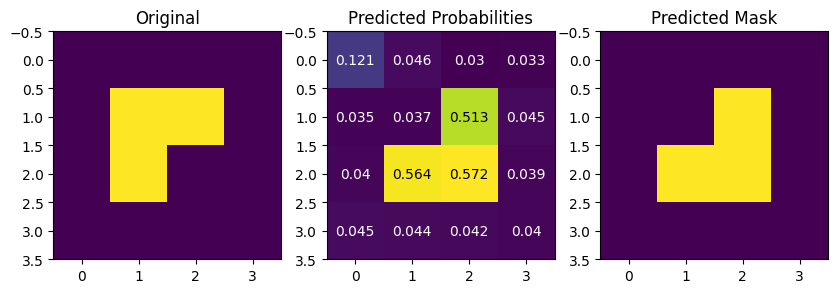

In [27]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize= (10,3*10))

ax1.imshow(dummpy_sample['labels'].squeeze(1)[0].cpu())
ax1.set_title("Original")

ax2.imshow(dummpy_sample['logits'].sigmoid().squeeze(1)[0].cpu())
for (j,i),label in np.ndenumerate(dummpy_sample['logits'].sigmoid().squeeze(1)[0].cpu()):
    if label < 0.5:
        color = 'white'
    else:
        color = 'black'
    ax2.text(i,j,round(label,3), color=color, ha='center',va='center')

ax2.set_title("Predicted Probabilities")

ax3.imshow((dummpy_sample['logits'].sigmoid() > 0.5).squeeze(1)[0].cpu())
ax3.set_title("Predicted Mask")

plt.show();

Проверяем на данном примере:

In [28]:
bce_loss_score = bce_loss(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu())
bce_true_score = bce_true(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu())
bce_torch_score = bce_torch(torch.sigmoid(dummpy_sample['logits'].cpu()), dummpy_sample['labels'].cpu().float())
bce_torch_with_logits_score = bce_torch_with_logits(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu().float())
assert np.isclose(bce_loss_score, bce_torch_score)
assert np.isclose(bce_loss_score, bce_torch_with_logits_score)
assert np.isclose(bce_true_score, bce_torch_score)
assert np.isclose(bce_true_score, bce_torch_with_logits_score)

## Шаг 4. Модель SegNet [2 балла]

Ваше задание здесь состоит в том, чтобы реализовать SegNet архитектуру.


* Badrinarayanan, V., Kendall, A., & Cipolla, R. (2015). [SegNet: A deep convolutional
encoder-decoder architecture for image segmentation](https://arxiv.org/pdf/1511.00561.pdf)

In [29]:
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
import torch.optim as optim
from time import time

from matplotlib import rcParams
rcParams['figure.figsize'] = (15,4)

Внимательно посмотрите из чего состоит модель и для чего выбраны те или иные блоки. Для этого скачаем и изучим feature extractor VGG-16, который лежит в основе SegNet.

In [30]:
model_vgg16 = models.vgg16(weights = models.VGG16_Weights.IMAGENET1K_V1)

In [31]:
model_vgg16

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

Feature extractor VGG-16 состоит из 5 блоков:
- два блока со структурой:
Conv2d -> ReLU -> Conv2d -> ReLU -> MaxPool2d
- три блока со структурой:
Conv2d -> ReLU -> Conv2d -> ReLU -> Conv2d -> ReLU -> MaxPool2d

В первом блоке - на входе три канала (по числу каналов в изображениях), которые конволюционный слой преобразует в 64 канала.

Во втором, третьем и четвертом блоках первый конволюционный слой удваивает количество каналов, а последующие конволюционные слои не меняют количество каналов.

В последнем блоке число каналов от слоя к слою не меняется.

Теперь напишем код одного блока энкодера нашей модели SegNet.  

In [32]:
# Параметрами блока будут:
# - количество каналов на входе
# - количество каналов на выходе
# - глубина блока (2 или 3, по количеству конволюционных слоев)
# - kernel_size и padding

class EncoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels, depth, kernel_size=3, padding=1):
        super(EncoderBlock, self).__init__() # инициируем экземляр класса, наследующего от nn.Module
        self.layers = nn.ModuleList() # в self.layers будем добавлять слои блока
        # дальше реализуем то, что на картинке выше обозначено Conv + Batch Normalization + ReLU
        self.layers.append(
            nn.Conv2d(
                in_channels=in_channels, 
                out_channels=out_channels, 
                kernel_size=kernel_size, 
                padding=padding
            )
        )
        self.layers.append(nn.BatchNorm2d(out_channels))
        self.layers.append(nn.ReLU(inplace=True))

        # цикл for помогает использовать один код для блоков как с глубиной 2, так и с глубиной 3
        for i in range(depth-1):
            self.layers.append(
                nn.Conv2d(
                    in_channels=out_channels, 
                    out_channels=out_channels, 
                    kernel_size=kernel_size, 
                    padding=padding
                )
            )
            self.layers.append(nn.BatchNorm2d(out_channels))
            self.layers.append(nn.ReLU(inplace=True))

        self.maxpooling = nn.MaxPool2d(kernel_size=2, stride=2, return_indices=True) # добавляем MaxPool с индексами для последующего Unpooling

    # Обратите внимание: на вход метод forward() получает карту признаков (х),
    # а возвращает карту признаков и индексы для последующего Unpooling
    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        x, indices=self.maxpooling(x)
        
        return x, indices


По аналогии напишите код одного блока декодера.

К карте признаков на входе каждого блока примеяется nn.MaxUnpool2d с индексами из симметричного блока энкодера. Затем повторяется связка Conv + Batch Normalization + ReLU. Количество каналов меняется зеркально блокам энкодера:
- в первом блоке декодера количество каналов не меняется
- во 2-4 блоках декодера количество каналов уменьшается в 2 раза после прохождения последнего конволюционного слоя
- на выходе из последнего блока декодера 1 канал

Обратите внимание, что после последней конволюции последнего блока декодера не применяется батч-нормализация и функция активации.

In [33]:
class DecoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels, depth, kernel_size=3, padding=1, is_last=False):
        super(DecoderBlock, self).__init__()  # инициируем экземляр класса, наследующего от nn.Module
        self.layers = nn.ModuleList()  # в self.layers будем добавлять слои блока

        # Unpooling
        self.unpooling = nn.MaxUnpool2d(kernel_size=2, stride=2)
        # дальше реализуем то, что на картинке выше обозначено Conv + Batch Normalization + ReLU
        # цикл for помогает использовать один код для блоков как с глубиной 2, так и с глубиной 3
        for i in range(depth - 1):
            self.layers.append(
                nn.Conv2d(in_channels=in_channels, 
                          out_channels=in_channels, 
                          kernel_size=kernel_size, 
                          padding=padding
                )
            )
            self.layers.append(nn.BatchNorm2d(in_channels))
            self.layers.append(nn.ReLU(inplace=True))

        self.layers.append(
            nn.Conv2d(in_channels=in_channels, 
                      out_channels=out_channels, 
                      kernel_size=kernel_size, 
                      padding=padding
            )
        )
        if not is_last:
            self.layers.append(nn.BatchNorm2d(out_channels))
            self.layers.append(nn.ReLU(inplace=True))

    def forward(self, x, indices):
        x = self.unpooling(x, indices)
        for layer in self.layers:
            x = layer(x)
        return x

Соединим блоки энкодера и декодера в модель SegNet:

In [34]:
class SegNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, num_features=64) -> None:
        super(SegNet, self).__init__()

        # Encoder
        self.encoder1 = EncoderBlock(in_channels, num_features, depth=2)                    # 3->64
        self.encoder2 = EncoderBlock(num_features, num_features * 2, depth=2)               # 64->128
        self.encoder3 = EncoderBlock(num_features * 2, num_features * 4, depth=3)           # 128->256
        self.encoder4 = EncoderBlock(num_features * 4, num_features * 8, depth=3)           # 256->512

        # Encoder bottleneck
        self.encoder5 = EncoderBlock(num_features * 8, num_features * 8, depth=3)           # 512->512

        # Decoder bottleneck
        self.decoder5 = DecoderBlock(num_features * 8, num_features * 8, depth=3)           # 512->512

        # Decoder
        self.decoder4 = DecoderBlock(num_features * 8, num_features * 4, depth=3)           # 512->256
        self.decoder3 = DecoderBlock(num_features * 4, num_features * 2, depth=3)           # 256->128
        self.decoder2 = DecoderBlock(num_features * 2, num_features, depth=2)               # 128->64
        self.decoder1 = DecoderBlock(num_features, out_channels, depth=2, is_last=True)     # 64->1

    def forward(self, x):
        # encoder
        x, indices1 = self.encoder1(x)
        x, indices2 = self.encoder2(x)
        x, indices3 = self.encoder3(x)
        x, indices4 = self.encoder4(x)
        x, indices5 = self.encoder5(x)

        # decoder
        x = self.decoder5(x, indices5)
        x = self.decoder4(x, indices4) 
        x = self.decoder3(x, indices3) 
        x = self.decoder2(x, indices2)
        output = self.decoder1(x, indices1)

        return output  # no activation

## Шаг 5. Тренировка модели [1 балл]

Напишите функции для обучения модели.

In [35]:
from tqdm.auto import tqdm
import copy
from IPython.display import clear_output

In [36]:
def plot_metrics(history, num_epochs):
    """
    Построение графиков обучения модели
    """

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    epochs = range(1, num_epochs + 1)
    # График loss
    ax1.plot(epochs, history['train_loss'], label='Train Loss')
    ax1.plot(epochs, history['val_loss'], label='Val Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Losses')
    ax1.legend()
    ax1.grid(True)

    # График IoU
    ax2.plot(epochs, history['train_iou'], label='Train IoU')
    ax2.plot(epochs, history['val_iou'], label='Val IoU')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('IoU Score')
    ax2.set_title('IoU Scores')
    ax2.legend()
    ax2.set_ylim(0.0, 1.0)
    ax2.grid(True)

    plt.tight_layout()

    # Лучшие метрики и эпохи
    best_val_loss = min(history['val_loss'])
    best_val_loss_epoch = history['val_loss'].index(best_val_loss) + 1

    best_val_iou = max(history['val_iou'])
    best_val_iou_epoch = history['val_iou'].index(best_val_iou) + 1

    print(
        f'Best Validation Loss:   {best_val_loss:.4f} (Epoch {best_val_loss_epoch})')
    print(
        f'Best Validation IoU:    {best_val_iou:.4f} (Epoch {best_val_iou_epoch})')

    return fig

In [37]:
def _iou_scalar(iou_tensor):
    """Одно число IoU из JaccardIndex (в т.ч. average='none')."""
    v = iou_tensor.float().mean() if iou_tensor.numel() > 0 else iou_tensor.float()
    return float(v.item())

In [38]:
def train_one_epoch(model, dataloader, criterion, optimizer, iou_metric, device):
    """
    Обучение модели на одной эпохе
    """
    model.train()
    running_loss = 0.0
    iou_metric.reset()

    for images, masks in tqdm(dataloader, desc='Training', leave=False):  # leave=True
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        with torch.no_grad():
            probs = torch.sigmoid(outputs)
            iou_metric.update(probs, masks.int())

    # Расчет метрик
    epoch_loss = running_loss / len(dataloader)
    epoch_iou = _iou_scalar(iou_metric.compute())

    return epoch_loss, epoch_iou

In [39]:
def eval_one_epoch(model, dataloader, criterion, iou_metric, device):
    """
    Валидация модели на одной эпохе
    """
    model.eval()
    running_loss = 0.0
    iou_metric.reset()

    with torch.no_grad():
        for images, masks in tqdm(dataloader, desc='Validation', leave=False):  # leave=True
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            loss = criterion(outputs, masks)

            running_loss += loss.item()

            probs = torch.sigmoid(outputs)
            iou_metric.update(probs, masks.int())

    # Расчет метрик
    epoch_loss = running_loss / len(dataloader)
    epoch_iou = _iou_scalar(iou_metric.compute())

    return epoch_loss, epoch_iou

In [40]:
def get_model_name(model, criterion_name):
    """
    Получение имени модели
    """
    model_class_name = model.__class__.__name__
    
    if model_class_name.endswith('Module'):
        model_class_name = model_class_name[:-6]
    
    return model_class_name.lower() + '_' + criterion_name

In [41]:
def train_model(model, loaders, criterion, optimizer, num_epochs, criterion_name,
                scheduler=None, iou_metric=None, device=None):
    """
    Полный цикл обучения модели
    """
    history = {
        'train_loss': [],
        'train_iou': [],
        'val_loss': [],
        'val_iou': []
    }

    if device is None:
        device = torch.device(
            'cuda' if torch.cuda.is_available() else
            'mps' if torch.backends.mps.is_available() else
            'cpu')
        
    print(f'Training on {device}')

    # Инициализация метрики
    if iou_metric is None:
        iou_metric = JaccardIndex(
            task='binary', threshold=0.5, average='binary'
        ).to(device)

    best_val_iou = -1.0
    best_epoch = 0
    best_model_state = None

    model_name = get_model_name(model, criterion_name)

    for epoch in range(num_epochs):

        # Обучение
        train_loss, train_iou = train_one_epoch(
            model, loaders['train'], criterion, optimizer, iou_metric, device)

        # Валидация
        val_loss, val_iou = eval_one_epoch(
            model, loaders['val'], criterion, iou_metric, device)

        # Сохранение истории
        history['train_loss'].append(train_loss)
        history['train_iou'].append(train_iou)
        history['val_loss'].append(val_loss)
        history['val_iou'].append(val_iou)

        # Запоминание лучшей модели
        if val_iou > best_val_iou:
            best_val_iou = val_iou
            best_epoch = epoch + 1
            best_model_state = copy.deepcopy(model.state_dict())
            print(f'Best IoU! Model saved!')

        clear_output(wait=True)

        plot_metrics(history, epoch+1)
        plt.show()

        # Вывод
        print(f'\nEpoch {epoch+1}/{num_epochs}')
        print(f'Train Loss: {train_loss:.4f} | IoU: {train_iou:.4f}')
        print(f'Val   Loss: {val_loss:.4f} | IoU: {val_iou:.4f}')

        # Обновление scheduler
        if scheduler is not None:
            if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss)
            else:
                scheduler.step()

    # Загрузка и сохранение лучшей модели
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

        model_path = f'models/best_{model_name}.pth'
        torch.save({
            'model_state_dict': best_model_state,
            'val_iou': best_val_iou,
            'epoch': best_epoch,
            'history': history,
            'model_name': model_name
        }, model_path)

    print(f'\nBest Validation IoU: {best_val_iou:.4f} on epoch {best_epoch}')

    return model, history, model_name

Обучите модель **SegNet**. В качестве оптимайзера можно взять Adam.

Выбор оптимайзера и планировщика буду выбирать, основываясь на максимальных итоговых значениях метрики IoU.

Best Validation Loss:   0.2114 (Epoch 49)
Best Validation IoU:    0.8551 (Epoch 49)


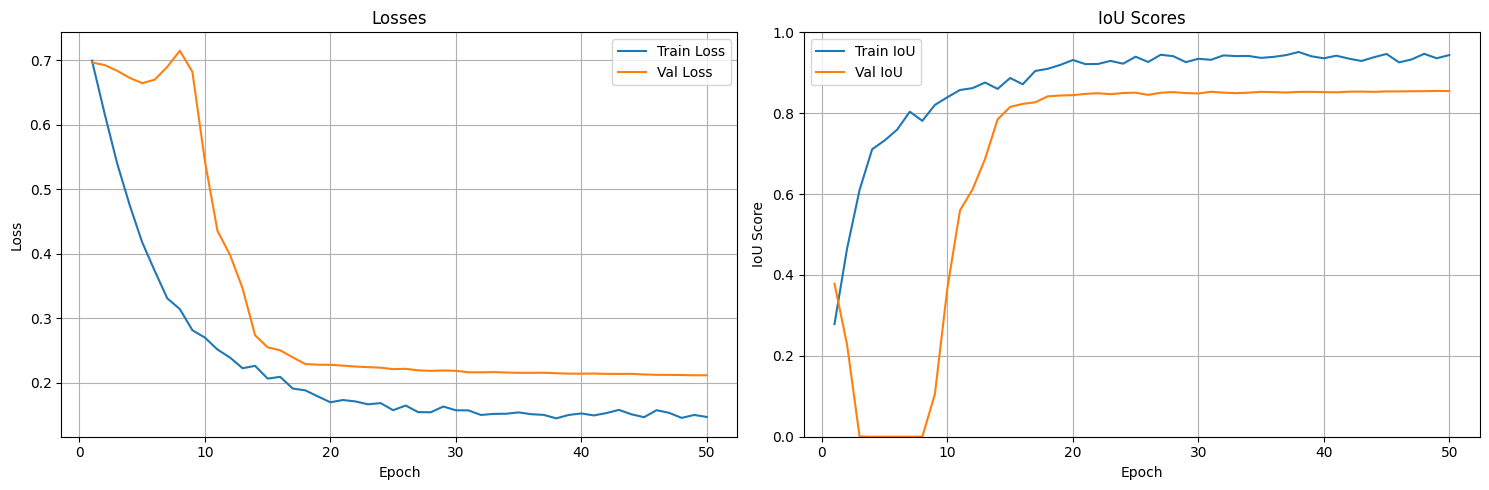


Epoch 50/50
Train Loss: 0.1468 | IoU: 0.9438
Val   Loss: 0.2114 | IoU: 0.8547

Best Validation IoU: 0.8551 on epoch 49


In [42]:
torch.cuda.empty_cache()

num_epochs = 50
criterion_name = 'bce'

model = SegNet(in_channels=3, out_channels=1, num_features=64).to(device)
criterion = nn.BCEWithLogitsLoss(reduction='mean')
# optimizer = optim.Adam(model.parameters(), lr=1e-3)
# optimizer = optim.Adam(model.parameters(), lr=1e-4)
# optimizer = optim.Adam(model.parameters(), lr=1e-5)
# optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
# optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
# scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)
# scheduler = None

segnet_model, segnet_history, segnet_model_name = train_model(
    model=model, 
    loaders=loaders, 
    criterion=criterion, 
    optimizer=optimizer, 
    num_epochs=num_epochs,
    criterion_name=criterion_name,
    scheduler=scheduler
)

## Шаг 6. Инференс [1 балл]

После обучения модели напишите функцию теста, воспользуйтесь лучшим чекпоинтом и протестируйте работу модели на тестовой выборке.

In [43]:
def test(model, dataloader, criterion, iou_metric=None,
         device=None, checkpoint_path='models/best_segnet_bce.pth'):
    
    # Загрузка сохраненного словаря
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)

    # Извлечение state_dict модели
    model_state_dict = checkpoint['model_state_dict']

    model.load_state_dict(model_state_dict)
    model.to(device)

    if device is None:
        device = torch.device(
            'cuda' if torch.cuda.is_available() else
            'mps' if torch.backends.mps.is_available() else
            'cpu')

    # Инициализация метрики
    if iou_metric is None:
        iou_metric = JaccardIndex(
            task='binary', threshold=0.5, average='binary'
        ).to(device)
        
    test_loss, test_iou = eval_one_epoch(
        model, dataloader, criterion, iou_metric, device)
    
    print(f'Test Loss: {test_loss:.4f} | IoU: {test_iou:.4f}')

In [44]:
torch.cuda.empty_cache()

model_name = segnet_model_name
checkpoint_path = f'models/best_{model_name}.pth'

test(
    model=segnet_model,
    dataloader=loaders['test'],
    criterion=criterion,
    checkpoint_path=checkpoint_path
)

Validation:   0%|          | 0/50 [00:00<?, ?it/s]

Test Loss: 0.1964 | IoU: 0.8549


# Задания: Мир других лоссов!

## Пробуем другие функции потерь [2 балла]

В данном разделе вам потребуется имплементировать две функции потерь: DICE и Focal loss.


### Dice Loss

Итак, давайте сначала пропишем dice_score.

In [45]:
def dice_score(logits: torch.Tensor, labels: torch.Tensor, threshold: float = 0.5, eps: float = 1e-8):
    probs = torch.sigmoid(logits)
    preds = (probs >= threshold).float()

    TP = (preds * labels).sum()
    FP = (preds * (1 - labels)).sum()
    FN = ((1 - preds) * labels).sum()
    
    score = (2 * TP + eps) / (2 * TP + FP + FN + eps)
    
    return score

Проверим на корректность функцию dice_score:

In [46]:
from torchmetrics.segmentation import DiceScore

dice = DiceScore(num_classes=1, average='micro').to(device)
dice(dummpy_sample['logits'].sigmoid(), dummpy_sample['labels'].to(int))

tensor(0.3158, device='cuda:0')

In [47]:
# from torchmetrics.classification import Dice

# dice = Dice(average='micro').to(device)
# dice(dummpy_sample['logits'].sigmoid(), dummpy_sample['labels'].to(int))

In [48]:
# Другой вариант лосса для прохожения assert

from torchmetrics.classification import BinaryF1Score

dice = BinaryF1Score(multidim_average='global').to(device)
dice(dummpy_sample['logits'].sigmoid(), dummpy_sample['labels'].to(int))

tensor(0.6667, device='cuda:0')

In [49]:
assert dice(dummpy_sample['logits'].sigmoid(), dummpy_sample['labels'].to(int)).item() == \
       dice_score(dummpy_sample['logits'], dummpy_sample['labels'])

Давайте теперь пропишем лосс и воспользуемся библиотекой `segmentation-models-pytorch`, чтобы убедиться в корректности нашей функции.

In [50]:
def dice_loss(logits: torch.Tensor, labels: torch.Tensor, eps=1e-8):
    probs = torch.sigmoid(logits)

    probs_flat = probs.view(probs.size(0), -1)
    labels_flat = labels.view(labels.size(0), -1)

    TP = (probs_flat * labels_flat).sum(dim=1)
    FP = (probs_flat * (1 - labels_flat)).sum(dim=1)
    FN = ((1 - probs_flat) * labels_flat).sum(dim=1)

    dice = (2 * TP + eps) / (2 * TP + FP + FN + eps)

    loss = 1 - dice

    return loss.mean()

Проверка на корректность:

In [51]:
# проверьте, что у вас установлена библиотека
#!pip install segmentation-models-pytorch

In [52]:
from segmentation_models_pytorch.losses import DiceLoss
dice_loss_torch = DiceLoss(mode='binary')
dice_loss_torch(dummpy_sample['logits'], dummpy_sample['labels'])

tensor(0.5756, device='cuda:0')

In [53]:
assert dice_loss_torch(dummpy_sample['logits'], dummpy_sample['labels'].to(int)) == dice_loss(dummpy_sample['logits'], dummpy_sample['labels'])

### Focal Loss

[**2. Focal loss:**](https://arxiv.org/pdf/1708.02002.pdf)

Окей, мы уже с вами умеем делать BCE loss:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

Проблема с этой потерей заключается в том, что она имеет тенденцию приносить пользу классу **большинства** (фоновому) по отношению к классу **меньшинства** ( переднему). Поэтому обычно применяются весовые коэффициенты к каждому классу:

$$\mathcal L_{wBCE}(y, \hat y) = -\sum_i \alpha_i\left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

Традиционно вес $\alpha_i$ определяется как обратная частота класса этого пикселя $i$, так что наблюдения миноритарного класса весят больше по отношению к классу большинства.


Из оригинальной статьи по [Focal Loss](https://arxiv.org/pdf/1708.02002.pdf):

$$p_t = \sigma(\hat y_i)y_i + (1 - \sigma(\hat y_i)) (1-y_i)$$

$$\mathcal L_{focal}(y, \hat y) = (1 - p_t)^{\gamma} \mathcal L_{BCE}(y_i, \hat y_i).$$

$$\mathcal L_{focal}(y, \hat y) = -\sum_i (1 - p_t)^{\gamma} \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

$$\mathcal L_{focal}(y, \hat y) = -\sum_i (1 - (\sigma(\hat y_i)y_i + (1 - \sigma(\hat y_i)) (1-y_i)))^{\gamma} \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

In [54]:
def focal_loss(y_real, y_pred, eps = 1e-8, gamma = 2):
    y_pred_prob = torch.sigmoid(y_pred)
    p_t = y_pred_prob * y_real + (1 - y_pred_prob) * (1 - y_real)
    focal_weight = (1 - p_t) ** gamma
    bce = - (y_real * torch.log(y_pred_prob + eps) + (1 - y_real) * torch.log(1 - y_pred_prob + eps))
    loss = focal_weight * bce
    
    return loss.sum()

Проверка корректности функции:

In [55]:
from torchvision.ops import sigmoid_focal_loss
sigmoid_focal_loss(dummpy_sample['logits'], dummpy_sample['labels'], alpha=-1, gamma=2, reduction='sum')

tensor(3.6161, device='cuda:0')

In [56]:
assert sigmoid_focal_loss(dummpy_sample['logits'], dummpy_sample['labels'], alpha=-1, gamma=2, reduction='sum') == focal_loss(dummpy_sample['labels'], dummpy_sample['logits'], gamma=2.0)

## [BONUS] Мир сегментационных лоссов [5 баллов]

В данном блоке предлагаем вам написать одну функцию потерь самостоятельно. Для этого необходимо прочитать статью и имплементировать ее, и провести численное сравнение с предыдущими функциями.
 **ВАЖНО:** за имплементацию одного лосса выдается только один балл. Чтобы получить все 5 баллов, будет необходимо имплементировать все 5 лоссов.

* [Physiological Inspired Deep Neural Networks for Emotion Recognition](https://ieeexplore.ieee.org/stamp/stamp.jsp?arnumber=8472816&tag=1)". IEEE Access, 6, 53930-53943.

* [Boundary loss for highly unbalanced segmentation](https://arxiv.org/abs/1812.07032)

* [Tversky loss function for image segmentation using 3D fully convolutional deep networks](https://arxiv.org/abs/1706.05721)

* [Correlation Maximized Structural Similarity Loss for Semantic Segmentation](https://arxiv.org/abs/1910.08711)

* [Topology-Preserving Deep Image Segmentation](https://papers.nips.cc/paper/8803-topology-preserving-deep-image-segmentation)

### Physiological Inspired Deep Neural Networks for Emotion Recognition

In [57]:
def physiological_inspired_loss(y_pred, y_real, alpha=0.7):
    """
    Физиологически вдохновлённая функция потерь
    """
    # BCE компонент
    bce_loss = F.binary_cross_entropy_with_logits(y_pred, y_real, reduction='mean')

    y_pred_prob = torch.sigmoid(y_pred)

    # Максимизация отклонения от 0.5
    physiological_component = torch.abs(y_pred_prob - 0.5).mean()

    total_loss = alpha * bce_loss + (1 - alpha) * physiological_component
    
    return total_loss

### Boundary loss for highly unbalanced segmentation

In [58]:
from scipy import ndimage

def compute_distance_transform(masks: torch.Tensor) -> torch.Tensor:
    """
    Вычисление карты расстояний до границ
    """

    device = masks.device
    result = torch.zeros_like(masks)

    for i in range(masks.shape[0]):  # по батчу
        for c in range(masks.shape[1]):  # по каналам
            mask = masks[i, c].cpu().numpy()
            # Расстояние до ближайшей 1 (объекта)
            dist1 = ndimage.distance_transform_edt(mask)
            # Расстояние до ближайшего 0 (фона)
            dist0 = ndimage.distance_transform_edt(1 - mask)
            # Комбинирование расстояний
            dist = dist1 + dist0
            result[i, c] = torch.from_numpy(dist).to(device)

    return result

def boundary_loss(logits: torch.Tensor, labels: torch.Tensor, eps=1e-8):
    """
    Boundary Loss для несбалансированной сегментации
    """

    # Вычисляние расстояния до границ для истинных масок
    dist_map = compute_distance_transform(labels)

    # Взвешенные потери по расстояниям
    boundary_weights = dist_map / (dist_map.max() + eps)

    # BCE с весами по расстояниям
    bce = F.binary_cross_entropy_with_logits(
        logits, labels, reduction='none'
    )
    
    weighted_bce = bce * boundary_weights

    return weighted_bce.mean()



### Tversky loss function for image segmentation using 3D fully convolutional deep networks

Как dice_loss, только добавлена ассиметрия коэффициентами alpha и beta

In [59]:
def tversky_loss(logits: torch.Tensor, labels: torch.Tensor, alpha=0.3, beta=0.7, eps=1e-8):
    """
    Tversky Loss для сегментации
    """
    pred = torch.sigmoid(logits)

    pred_flat = pred.view(pred.size(0), -1)
    labels_flat = labels.view(labels.size(0), -1)

    TP = (pred_flat * labels_flat).sum(dim=1)
    FP = (pred_flat * (1 - labels_flat)).sum(dim=1)
    FN = ((1 - pred_flat) * labels_flat).sum(dim=1)

    tversky = (TP + eps) / (TP + alpha * FP + beta * FN + eps)
    
    loss = 1 - tversky

    return loss.mean()

### Correlation Maximized Structural Similarity Loss for Semantic Segmentation

In [60]:
def cssim_loss(logits, target, window_size=3, sigma=1.5, beta=0.1, lambda_weight=0.5, eps=1e-8):
    """
    Correlation Maximized Structural Similarity Loss (SSL)
    Возвращает комбинированный loss: lambda_weight * BCE + (1-lambda_weight) * SSL
    """
    def gaussian_window_1d(size, sigma):
        """
        Создание Гауссовского окна 
        """
        coords = torch.arange(size, dtype=torch.float32, device=logits.device) - size // 2
        g = torch.exp(-(coords ** 2) / (2 * sigma ** 2))
        return g / (g.sum() + eps)
    
    # Гауссово окно
    _1d = gaussian_window_1d(window_size, sigma).unsqueeze(1)
    _2d = _1d.mm(_1d.t()).unsqueeze(0).unsqueeze(0)
    
    pred = torch.sigmoid(logits)
    C = pred.shape[1]
    window = _2d.expand(C, 1, window_size, window_size).contiguous()
    
    # Локальные статистики
    mu_y = F.conv2d(target, window, padding=window_size//2, groups=C)
    mu_p = F.conv2d(pred, window, padding=window_size//2, groups=C)
    
    # Для target
    sigma2_y = torch.clamp(mu_y - mu_y.pow(2), min=eps)
    sigma_y = torch.sqrt(sigma2_y)
    
    # Для pred
    sigma2_p = torch.clamp(
        F.conv2d(pred.pow(2), window, padding=window_size//2, groups=C) - mu_p.pow(2),
        min=eps
    )
    sigma_p = torch.sqrt(sigma2_p)
    
    # Нормализация
    C4 = 0.01
    y_nor = (target - mu_y + C4) / (sigma_y + C4)
    p_nor = (pred - mu_p + C4) / (sigma_p + C4)
    
    # Ошибка структурного несходства
    e = torch.abs(y_nor - p_nor)
    
    # Замена nan на 0
    e = torch.nan_to_num(e, nan=0.0, posinf=0.0, neginf=0.0)
    
    # Hard examples
    emax = e.detach().max()
    
    # Если emax слишком маленький или 0, используется вся карта как hard examples
    if emax < eps:
        hard_mask = torch.ones_like(e)
        M = hard_mask.sum()
    else:
        hard_mask = (e > beta * emax).float()
        M = hard_mask.sum()
        
        # Если hard examples слишком мало, используется вся карта
        if M < 10:  # минимум 10 пикселей
            hard_mask = torch.ones_like(e)
            M = hard_mask.sum()
    
    # BCE
    bce = F.binary_cross_entropy_with_logits(logits, target.float(), reduction='none')
    
    # SSL
    ssl = (e.detach() * hard_mask * bce).sum() / M
    
    # Замена nan на 0
    ssl = torch.nan_to_num(ssl, nan=0.0, posinf=0.0, neginf=0.0)
    
    # BCE компонента
    bce_loss = F.binary_cross_entropy_with_logits(logits, target.float(), reduction='mean')
    
    # Комбинированный loss
    total_loss = lambda_weight * bce_loss + (1 - lambda_weight) * ssl
    
    return total_loss

### Topology-Preserving Deep Image Segmentation

In [61]:
from scipy.ndimage import distance_transform_edt

def batch_distance_transform(masks):
    """
    Вычисление карты расстояний для батча истинных масок (для target)
    """
    device = masks.device
    masks_np = masks.detach().cpu().numpy()
    batch_size = masks_np.shape[0]
    dists = []
    
    for i in range(batch_size):
        mask = masks_np[i, 0]
        # Расстояние до ближайшей 1 (объекта)
        pos_dist = distance_transform_edt(mask)
        # Расстояние до ближайшего 0 (фона)
        neg_dist = distance_transform_edt(1 - mask)
        # Определение границы
        combined_dist = pos_dist - neg_dist
        dists.append(combined_dist)
    
    dist_tensor = torch.from_numpy(np.stack(dists)).float().to(device)
    return dist_tensor.unsqueeze(1)


def batch_distance_transform_soft(probs, threshold=0.5, sigma=10.0):
    """
    Вычисление карты расстояний для батча предсказанных масок (для pred)
    """
    soft_mask = torch.sigmoid(sigma * (probs - threshold))
    
    batch_size = soft_mask.shape[0]
    dists = []
    

    # Применение свертки для размазывания границ, имитируя распространение расстояния от границы
    for i in range(batch_size):
        prob_map = soft_mask[i, 0]
        
        kernel_size = 7
        kernel = torch.ones(1, 1, kernel_size, kernel_size).to(probs.device) / (kernel_size**2)
        smoothed = prob_map.unsqueeze(0).unsqueeze(0)

        # Применяем 3 раза размытие границ 
        for _ in range(3):
            smoothed = F.conv2d(smoothed, kernel, padding=kernel_size//2)
        
        dists.append(smoothed.squeeze())
    
    return torch.stack(dists).unsqueeze(1)


def topology_preserving_loss(logits, target, alpha=0.1, eps=1e-8):
    """
    Topology-Preserving Deep Image Segmentation
    """
    pred = torch.sigmoid(logits)
    
    # BCE компонент
    bce_loss = F.binary_cross_entropy_with_logits(logits, target, reduction='mean')
    
    # Топологический компонент
    with torch.no_grad():
        # Карта расстояний для истинной маски (target)
        target_dist = batch_distance_transform(target)
        # Нормализация карты расстояний target
        target_dist = target_dist / (target_dist.abs().max() + eps)

    # Карта расстояний для предсказанной маски (pred)
    pred_dist = batch_distance_transform_soft(pred)
    # Нормализация карты расстояний pred
    pred_dist = pred_dist / (pred_dist.abs().max() + eps)
    
    # Сравнивнение карт расстояний (как сильно совпали)
    topo_loss = F.mse_loss(pred_dist, target_dist, reduction='mean')
    
    return bce_loss + alpha * topo_loss

## Обучите SegNet на новых лоссах

**Задание**: обучите SegNet на новых лоссах и сравните все три лосса:
*   При каком лоссе модель сходится быстрее?
*   При каком лоссе модель выдает наилучшую метрику?

Напишите развернутый ответ на вопросы.



### SegNet BCE loss

Best Validation Loss:   0.1848 (Epoch 49)
Best Validation IoU:    0.8619 (Epoch 25)


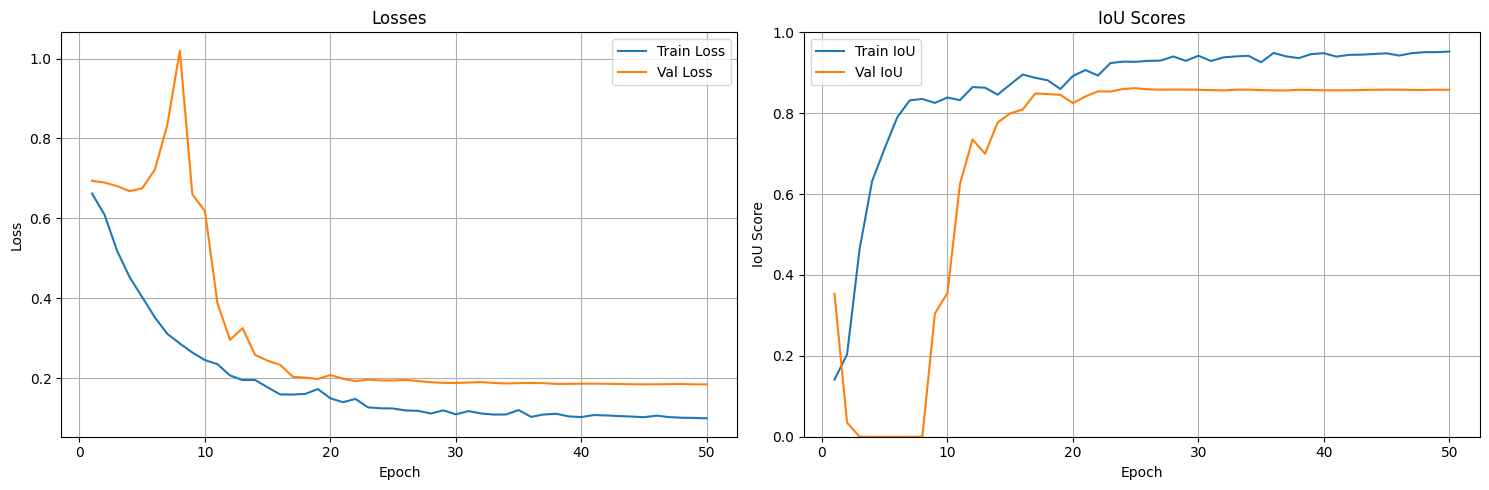


Epoch 50/50
Train Loss: 0.0999 | IoU: 0.9525
Val   Loss: 0.1849 | IoU: 0.8580

Best Validation IoU: 0.8619 on epoch 25


In [62]:
torch.cuda.empty_cache()

num_epochs = 50
criterion_name = 'bce'

model = SegNet(in_channels=3, out_channels=1, num_features=64).to(device)
criterion = nn.BCEWithLogitsLoss(reduction='mean')
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
# optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
# scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

segnet_bce_model, segnet_bce_history, segnet_bce_model_name = train_model(
    model=model, 
    loaders=loaders, 
    criterion=criterion, 
    optimizer=optimizer, 
    num_epochs=num_epochs,
    criterion_name=criterion_name,
    scheduler=scheduler
)

In [63]:
torch.cuda.empty_cache()

model, model_name = segnet_bce_model, segnet_bce_model_name
checkpoint_path = f'models/best_{model_name}.pth'

test(
    model=model,
    dataloader=loaders['test'],
    criterion=criterion,
    checkpoint_path=checkpoint_path
)

Validation:   0%|          | 0/50 [00:00<?, ?it/s]

Test Loss: 0.1734 | IoU: 0.8607


### SegNet Dice loss

Best Validation Loss:   0.1617 (Epoch 47)
Best Validation IoU:    0.8572 (Epoch 34)


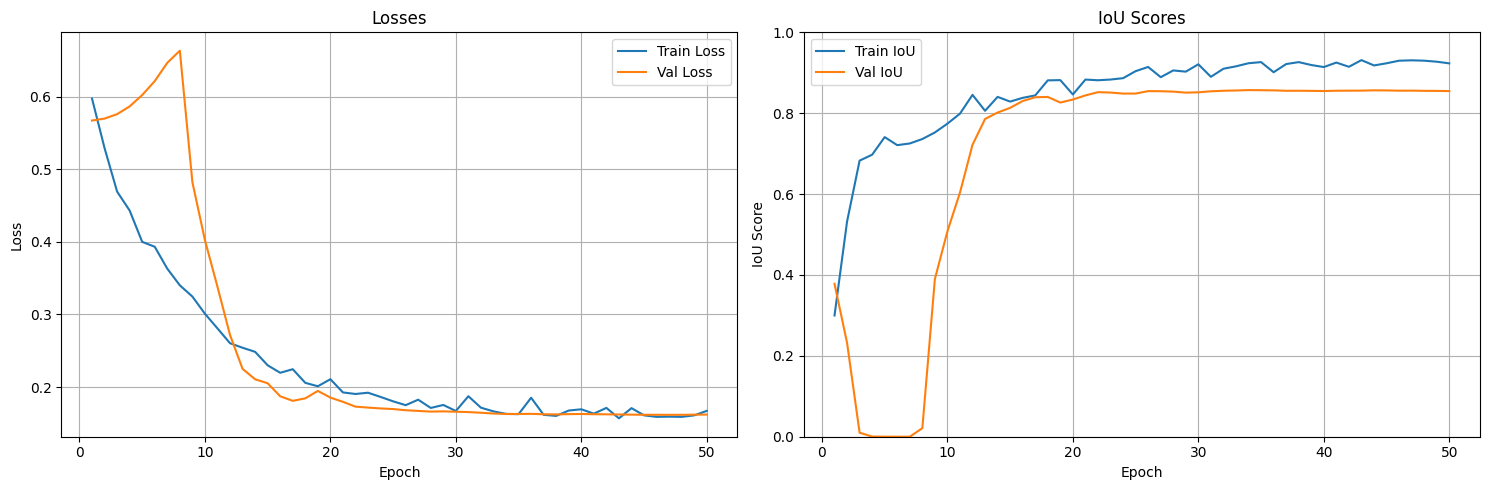


Epoch 50/50
Train Loss: 0.1672 | IoU: 0.9233
Val   Loss: 0.1621 | IoU: 0.8547

Best Validation IoU: 0.8572 on epoch 34


In [64]:
torch.cuda.empty_cache()

num_epochs = 50
criterion_name = 'dice'

model = SegNet(in_channels=3, out_channels=1, num_features=64).to(device)
criterion = DiceLoss(mode='binary')
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
# optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
# scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

segnet_dice_model, segnet_dice_history, segnet_dice_model_name = train_model(
    model=model, 
    loaders=loaders, 
    criterion=criterion, 
    optimizer=optimizer, 
    num_epochs=num_epochs,
    criterion_name=criterion_name,
    scheduler=scheduler
)

In [65]:
torch.cuda.empty_cache()

model, model_name = segnet_dice_model, segnet_dice_model_name
checkpoint_path = f'models/best_{model_name}.pth'

test(
    model=model,
    dataloader=loaders['test'],
    criterion=criterion,
    checkpoint_path=checkpoint_path
)

Validation:   0%|          | 0/50 [00:00<?, ?it/s]

Test Loss: 0.2473 | IoU: 0.8709


### SegNet Focal loss

In [66]:
def focal_loss(y_pred, y_real, gamma=2):
    y_pred_prob = torch.sigmoid(y_pred)
    p_t = y_pred_prob * y_real + (1 - y_pred_prob) * (1 - y_real)
    bce = F.binary_cross_entropy_with_logits(y_pred, y_real.float(), reduction='none')
    focal_weight = (1 - p_t) ** gamma
    loss = focal_weight * bce
    
    return loss.mean()

Best Validation Loss:   0.0434 (Epoch 25)
Best Validation IoU:    0.8550 (Epoch 31)


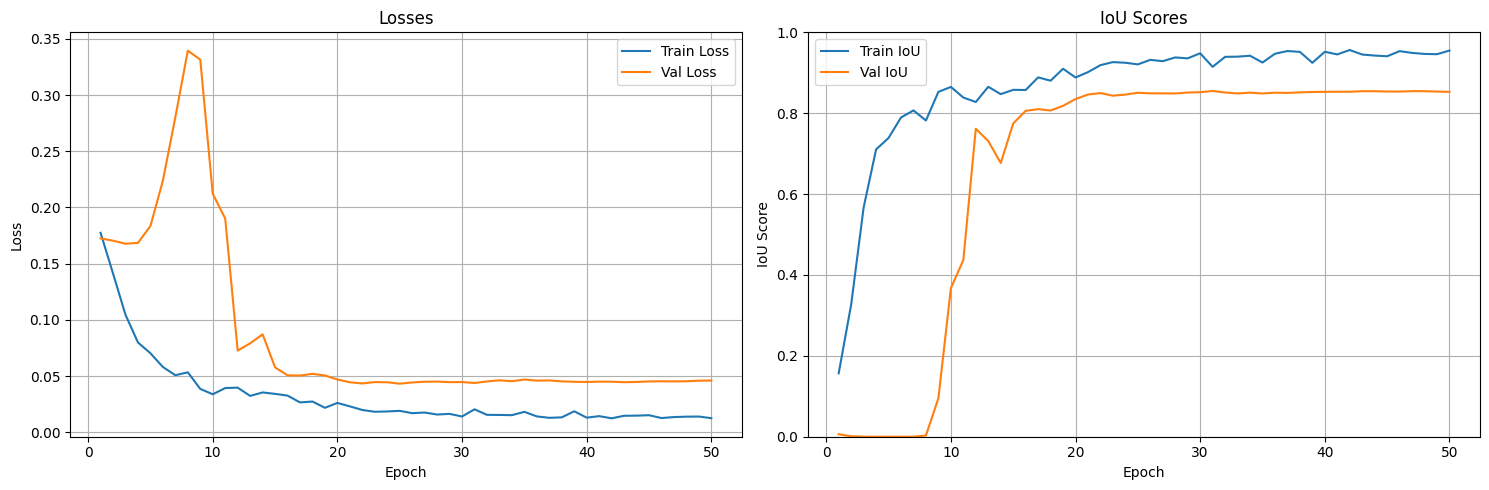


Epoch 50/50
Train Loss: 0.0127 | IoU: 0.9549
Val   Loss: 0.0462 | IoU: 0.8529

Best Validation IoU: 0.8550 on epoch 31


In [67]:
torch.cuda.empty_cache()

num_epochs = 50
criterion_name = 'focal'

model = SegNet(in_channels=3, out_channels=1, num_features=64).to(device)
criterion = focal_loss
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
# optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
# scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

segnet_focal_model, segnet_focal_history, segnet_focal_model_name = train_model(
    model=model, 
    loaders=loaders, 
    criterion=criterion, 
    optimizer=optimizer, 
    num_epochs=num_epochs,
    criterion_name=criterion_name,
    scheduler=scheduler
)

In [68]:
torch.cuda.empty_cache()

model, model_name = segnet_focal_model, segnet_focal_model_name
checkpoint_path = f'models/best_{model_name}.pth'

test(
    model=model,
    dataloader=loaders['test'],
    criterion=criterion,
    checkpoint_path=checkpoint_path
)

Validation:   0%|          | 0/50 [00:00<?, ?it/s]

Test Loss: 0.0313 | IoU: 0.8726


### SegNet Physiological inspired loss

Best Validation Loss:   0.2469 (Epoch 40)
Best Validation IoU:    0.8647 (Epoch 36)


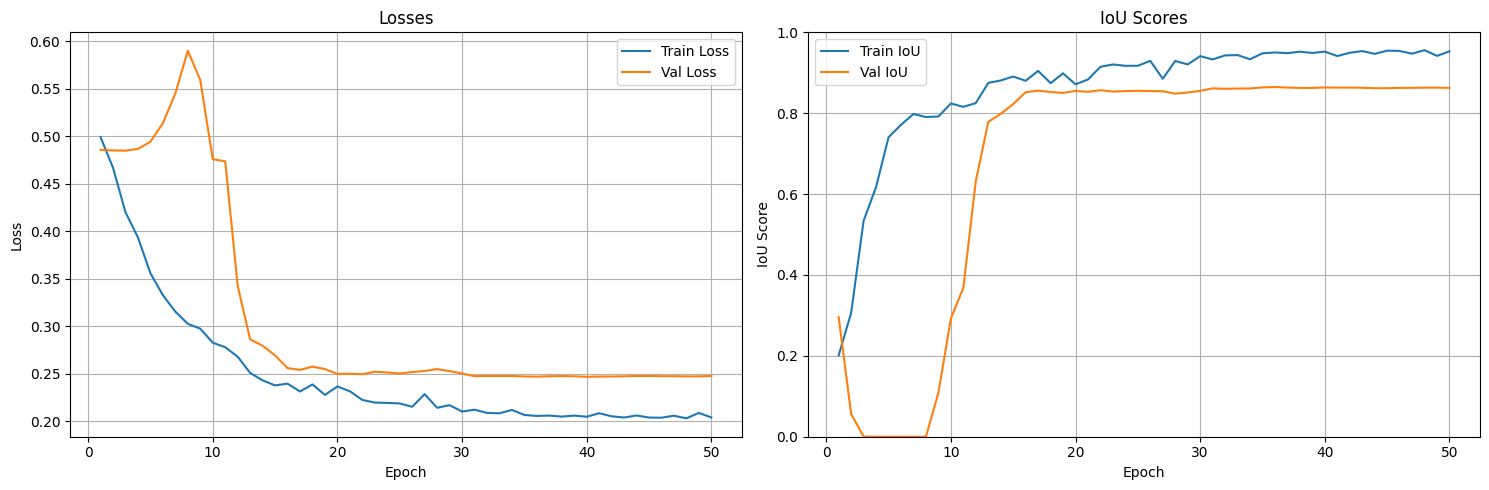


Epoch 50/50
Train Loss: 0.2041 | IoU: 0.9530
Val   Loss: 0.2478 | IoU: 0.8627

Best Validation IoU: 0.8647 on epoch 36


In [69]:
torch.cuda.empty_cache()

num_epochs = 50
criterion_name = 'physiological_inspired'

model = SegNet(in_channels=3, out_channels=1, num_features=64).to(device)
criterion = physiological_inspired_loss
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
# optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
# scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

segnet_physiological_inspired_model, segnet_physiological_inspired_history, segnet_physiological_inspired_model_name = train_model(
    model=model, 
    loaders=loaders, 
    criterion=criterion, 
    optimizer=optimizer, 
    num_epochs=num_epochs,
    criterion_name=criterion_name,
    scheduler=scheduler
)

In [70]:
torch.cuda.empty_cache()

model, model_name = segnet_physiological_inspired_model, segnet_physiological_inspired_model_name
checkpoint_path = f'models/best_{model_name}.pth'

test(
    model=model,
    dataloader=loaders['test'],
    criterion=criterion,
    checkpoint_path=checkpoint_path
)

Validation:   0%|          | 0/50 [00:00<?, ?it/s]

Test Loss: 0.2289 | IoU: 0.8839


### SegNet Boundary loss

Best Validation Loss:   0.0317 (Epoch 46)
Best Validation IoU:    0.8147 (Epoch 19)


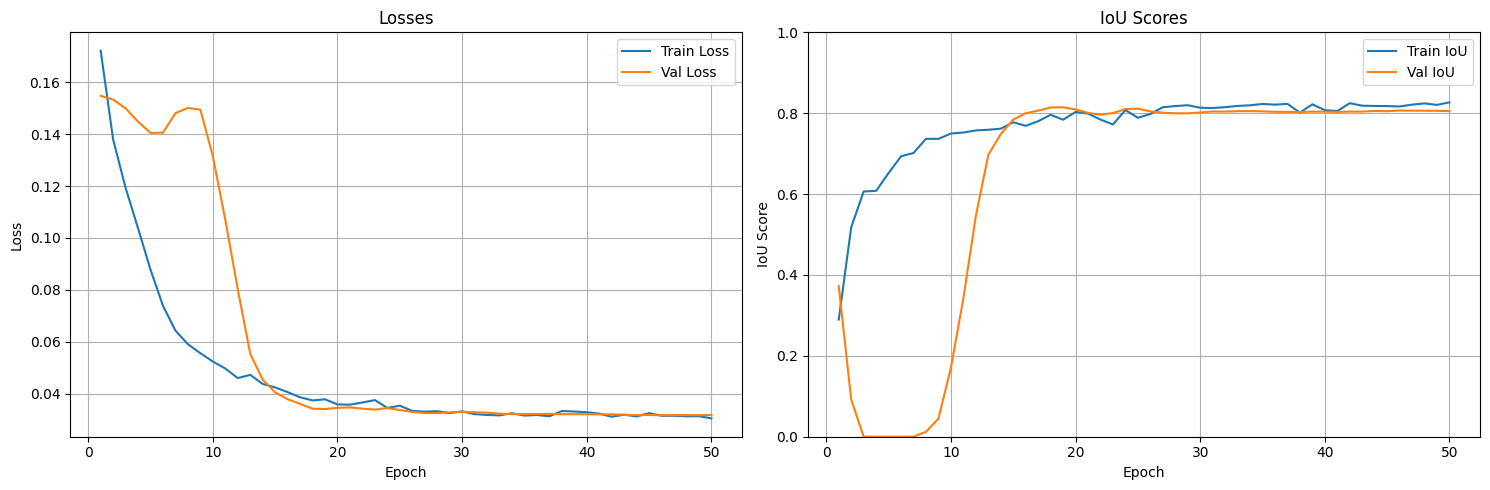


Epoch 50/50
Train Loss: 0.0305 | IoU: 0.8268
Val   Loss: 0.0318 | IoU: 0.8052

Best Validation IoU: 0.8147 on epoch 19


In [71]:
torch.cuda.empty_cache()

num_epochs = 50
criterion_name = 'boundary'

model = SegNet(in_channels=3, out_channels=1, num_features=64).to(device)
criterion = boundary_loss
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
# optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
# scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

segnet_boundary_model, segnet_boundary_history, segnet_boundary_model_name = train_model(
    model=model, 
    loaders=loaders, 
    criterion=criterion, 
    optimizer=optimizer, 
    num_epochs=num_epochs,
    criterion_name=criterion_name,
    scheduler=scheduler
)

In [72]:
torch.cuda.empty_cache()

model, model_name = segnet_boundary_model, segnet_boundary_model_name
checkpoint_path = f'models/best_{model_name}.pth'

test(
    model=model,
    dataloader=loaders['test'],
    criterion=criterion,
    checkpoint_path=checkpoint_path
)

Validation:   0%|          | 0/50 [00:00<?, ?it/s]

Test Loss: 0.0475 | IoU: 0.8047


### SegNet Tversky loss

Best Validation Loss:   0.1550 (Epoch 48)
Best Validation IoU:    0.8458 (Epoch 23)


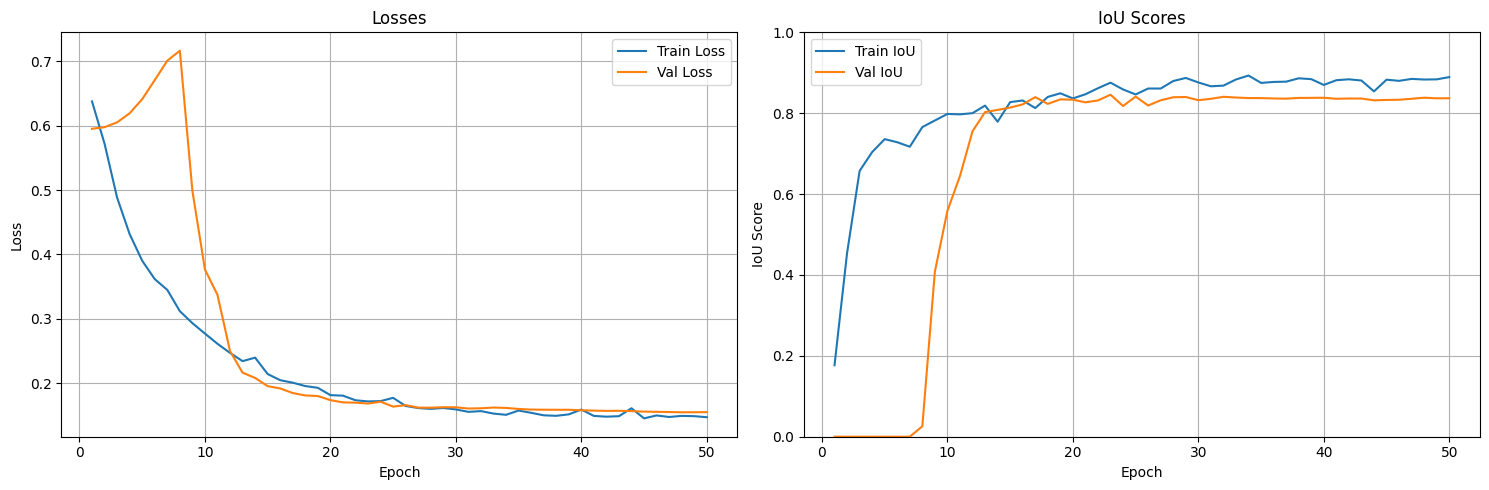


Epoch 50/50
Train Loss: 0.1473 | IoU: 0.8893
Val   Loss: 0.1552 | IoU: 0.8371

Best Validation IoU: 0.8458 on epoch 23


In [73]:
torch.cuda.empty_cache()

num_epochs = 50
criterion_name = 'tversky'

model = SegNet(in_channels=3, out_channels=1, num_features=64).to(device)
criterion = tversky_loss
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
# optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
# scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

segnet_tversky_model, segnet_tversky_history, segnet_tversky_model_name = train_model(
    model=model, 
    loaders=loaders, 
    criterion=criterion, 
    optimizer=optimizer, 
    num_epochs=num_epochs,
    criterion_name=criterion_name,
    scheduler=scheduler
)

In [74]:
torch.cuda.empty_cache()

model, model_name = segnet_tversky_model, segnet_tversky_model_name
checkpoint_path = f'models/best_{model_name}.pth'

test(
    model=model,
    dataloader=loaders['test'],
    criterion=criterion,
    checkpoint_path=checkpoint_path
)

Validation:   0%|          | 0/50 [00:00<?, ?it/s]

Test Loss: 0.1874 | IoU: 0.8245


### SegNet Cssim loss

Best Validation Loss:   0.2175 (Epoch 37)
Best Validation IoU:    0.8659 (Epoch 32)


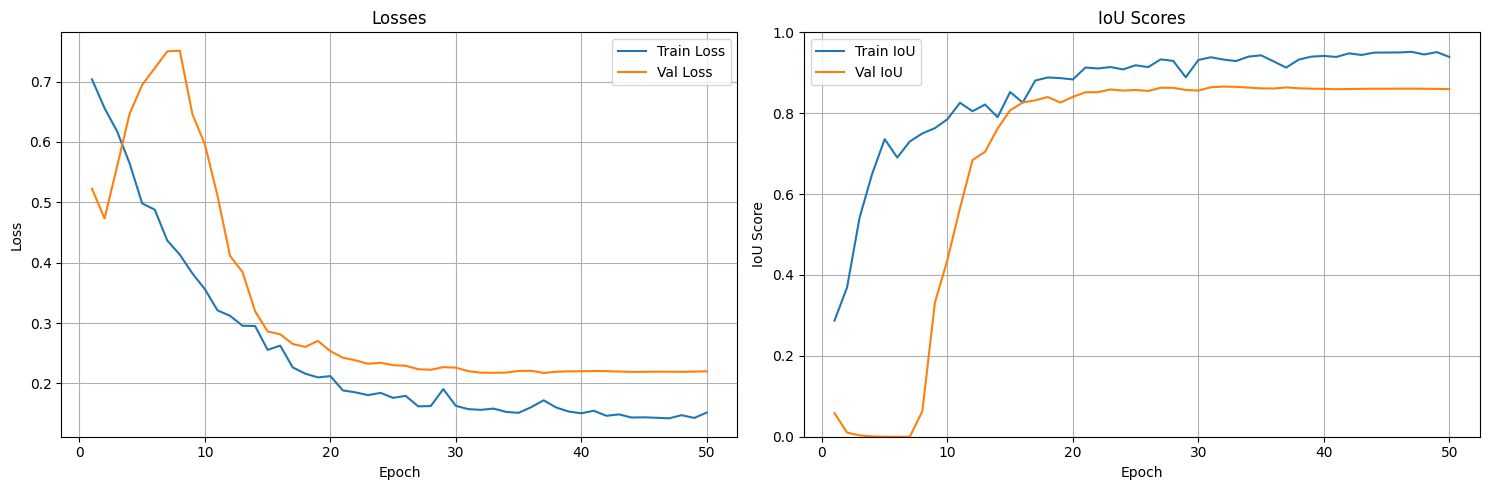


Epoch 50/50
Train Loss: 0.1518 | IoU: 0.9391
Val   Loss: 0.2202 | IoU: 0.8596

Best Validation IoU: 0.8659 on epoch 32


In [75]:
torch.cuda.empty_cache()

num_epochs = 50
criterion_name = 'cssim'

model = SegNet(in_channels=3, out_channels=1, num_features=64).to(device)
criterion = cssim_loss
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
# optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
# scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

segnet_cssim_model, segnet_cssim_history, segnet_cssim_model_name = train_model(
    model=model, 
    loaders=loaders, 
    criterion=criterion, 
    optimizer=optimizer, 
    num_epochs=num_epochs,
    criterion_name=criterion_name,
    scheduler=scheduler
)

In [76]:
torch.cuda.empty_cache()

model, model_name = segnet_cssim_model, segnet_cssim_model_name
checkpoint_path = f'models/best_{model_name}.pth'

test(
    model=model,
    dataloader=loaders['test'],
    criterion=criterion,
    checkpoint_path=checkpoint_path
)

Validation:   0%|          | 0/50 [00:00<?, ?it/s]

Test Loss: 0.2025 | IoU: 0.8631


### SegNet topology_preserving loss

Best Validation Loss:   0.2104 (Epoch 37)
Best Validation IoU:    0.8464 (Epoch 23)


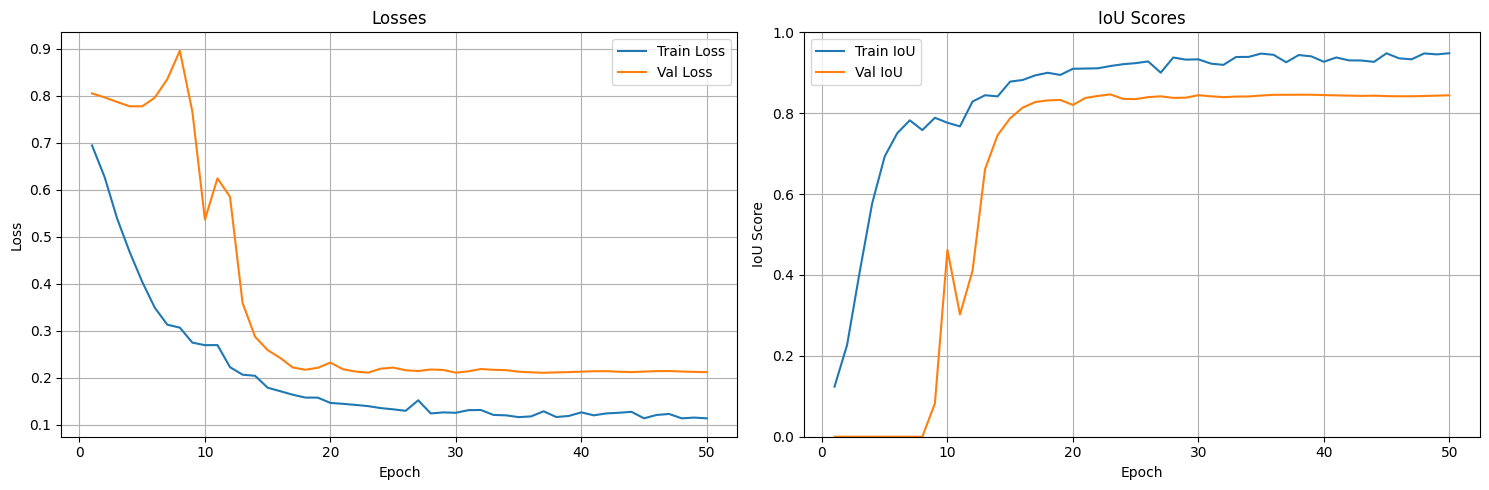


Epoch 50/50
Train Loss: 0.1134 | IoU: 0.9483
Val   Loss: 0.2117 | IoU: 0.8443

Best Validation IoU: 0.8464 on epoch 23


In [77]:
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

torch.cuda.empty_cache()

num_epochs = 50
criterion_name = 'topology_preserving'

model = SegNet(in_channels=3, out_channels=1, num_features=64).to(device)
criterion = topology_preserving_loss
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
# optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
# scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

segnet_topology_preserving_model, segnet_topology_preserving_history, segnet_topology_preserving_model_name = train_model(
    model=model, 
    loaders=loaders, 
    criterion=criterion, 
    optimizer=optimizer, 
    num_epochs=num_epochs,
    criterion_name=criterion_name,
    scheduler=scheduler
)

In [78]:
torch.cuda.empty_cache()

model, model_name = segnet_topology_preserving_model, segnet_topology_preserving_model_name
checkpoint_path = f'models/best_{model_name}.pth'

test(
    model=model,
    dataloader=loaders['test'],
    criterion=criterion,
    checkpoint_path=checkpoint_path
)

Validation:   0%|          | 0/50 [00:00<?, ?it/s]

Test Loss: 0.1876 | IoU: 0.8409


### Сравнение моделей SegNet с различными функциями потерь

In [79]:
def plot_metrics_full(models_to_compare):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 12))

    # Цвета для моделей (чтобы на обоих графиках цвета совпадали)
    colors = plt.cm.tab10(np.linspace(0, 1, len(models_to_compare)))

    for idx, (model, history, name) in enumerate(models_to_compare):
        num_epochs = len(history['train_loss'])
        epochs = range(1, num_epochs + 1)
        color = colors[idx]

        # График Loss
        # ax1.plot(epochs, history['train_loss'],
        #         label=f'{name} - Train Loss', color=color, linestyle='-', linewidth=2)
        ax1.plot(epochs, history['val_loss'], label=f'{name} - Val Loss', color=color)

        # График IoU
        # ax2.plot(epochs, history['train_iou'],
        #         label=f'{name} - Train IoU', color=color, linestyle='-', linewidth=2)
        ax2.plot(epochs, history['val_iou'], label=f'{name} - Val IoU', color=color)

    # Оформляем график Loss
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Losses')
    ax1.legend()
    # ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax1.grid(True)

    # Оформляем график IoU
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('IoU Score')
    ax2.set_title('IoU Scores')
    ax2.set_ylim(0.0, 1.0)
    ax2.legend()
    ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax2.grid(True)

    plt.tight_layout()

    return fig

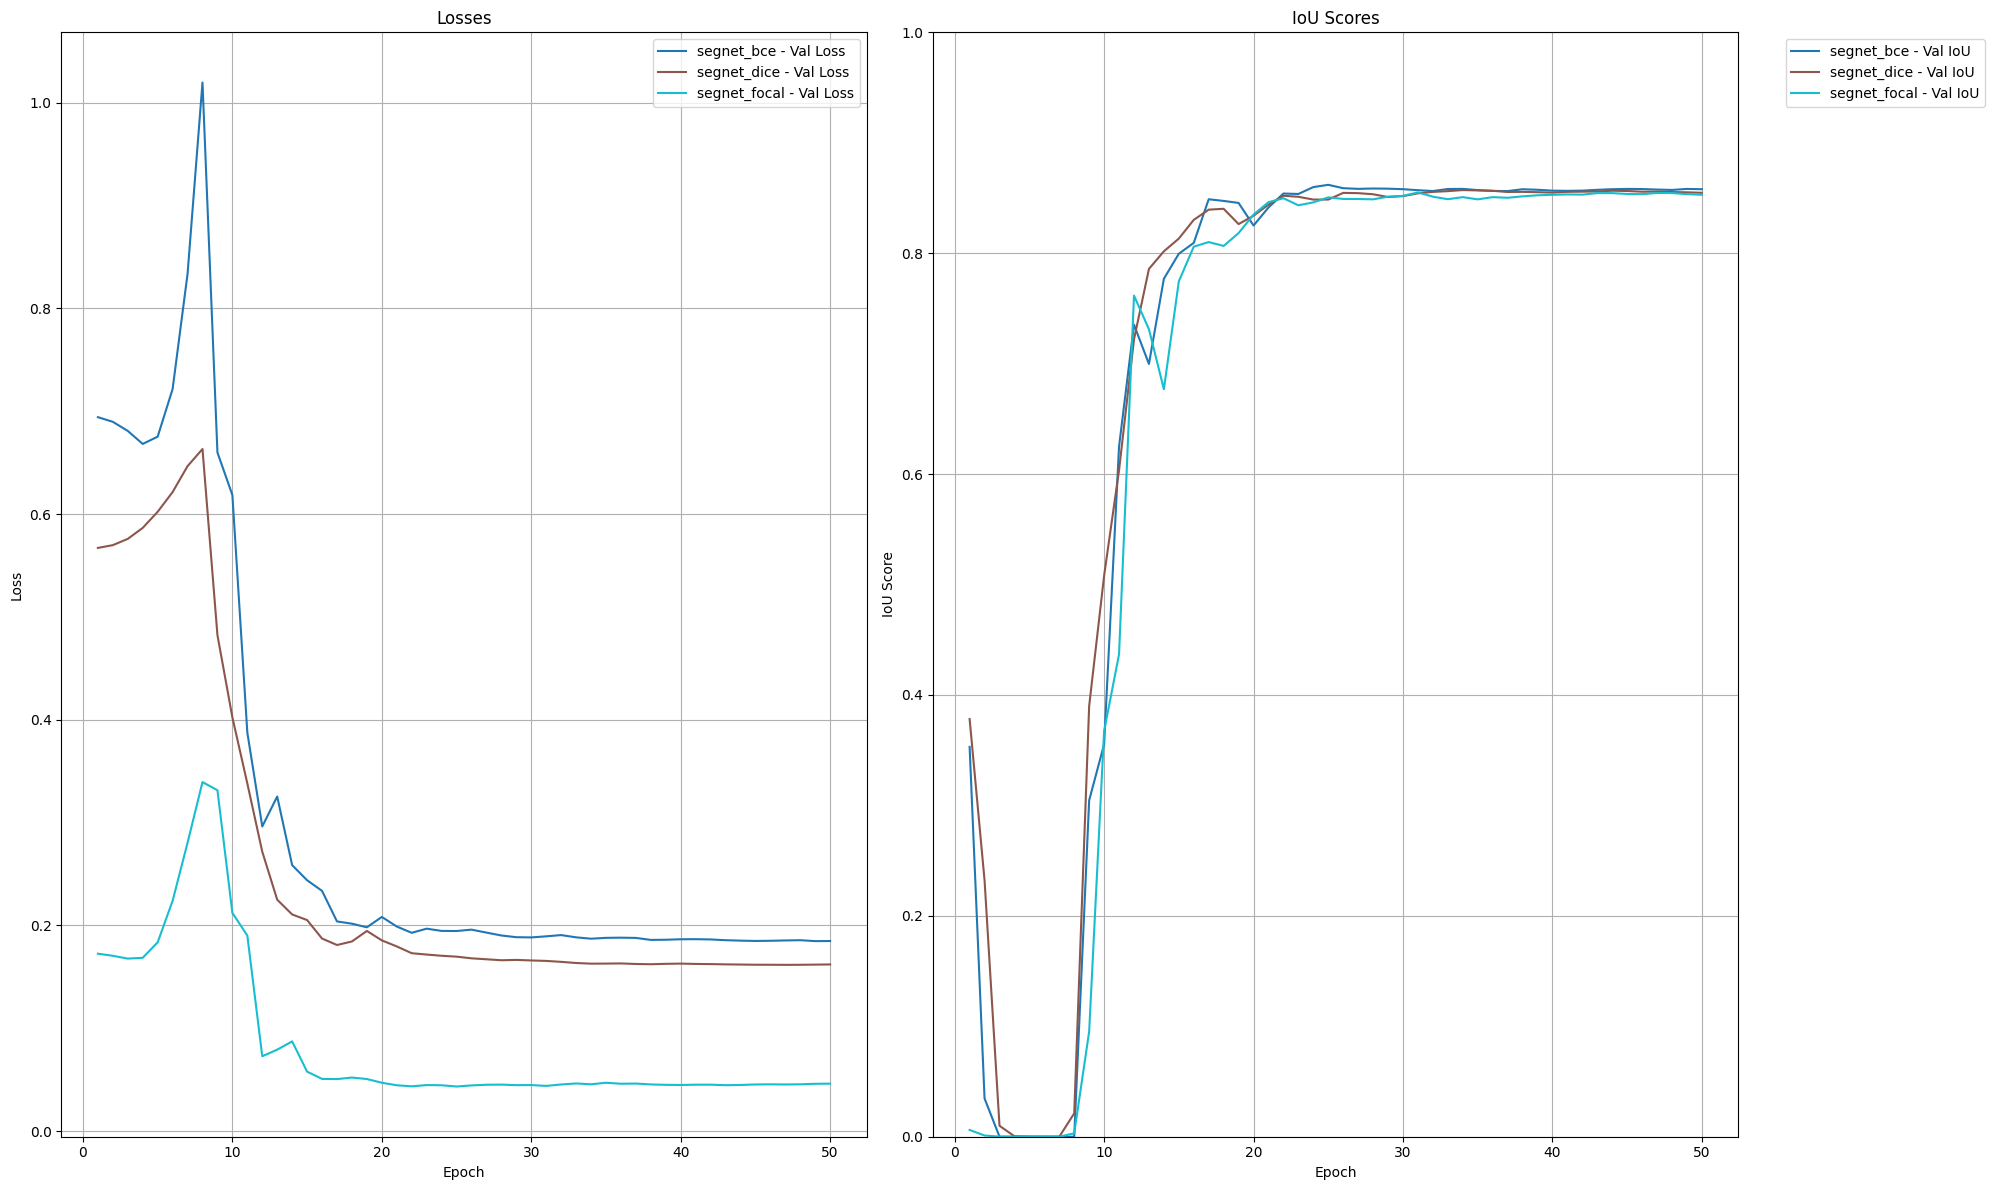

In [80]:
# Список моделей для сравнения (по заданию)
segnet_models_to_compare_light = [
    (segnet_bce_model, segnet_bce_history, segnet_bce_model_name),
    (segnet_dice_model, segnet_dice_history, segnet_dice_model_name),
    (segnet_focal_model, segnet_focal_history, segnet_focal_model_name)
]

plot_metrics_full(segnet_models_to_compare_light)
plt.show();

### Ответы на вопросы

см. Финальная таблица сравнения моделей (в конце ноутбука)

*   При каком лоссе модель сходится быстрее?  
Модель SegNet с BCE Loss сходится быстрее остальных моделей SegNet.
*   При каком лоссе модель выдает наилучшую метрику?  
Модель SegNet c BCE Loss выдает наилучшую метрику среди моделей SegNet.  
Быстрая сходимость объсняется простотой функции потерь BCE Loss.  
По метрике IoU получились довольно близкие значения.

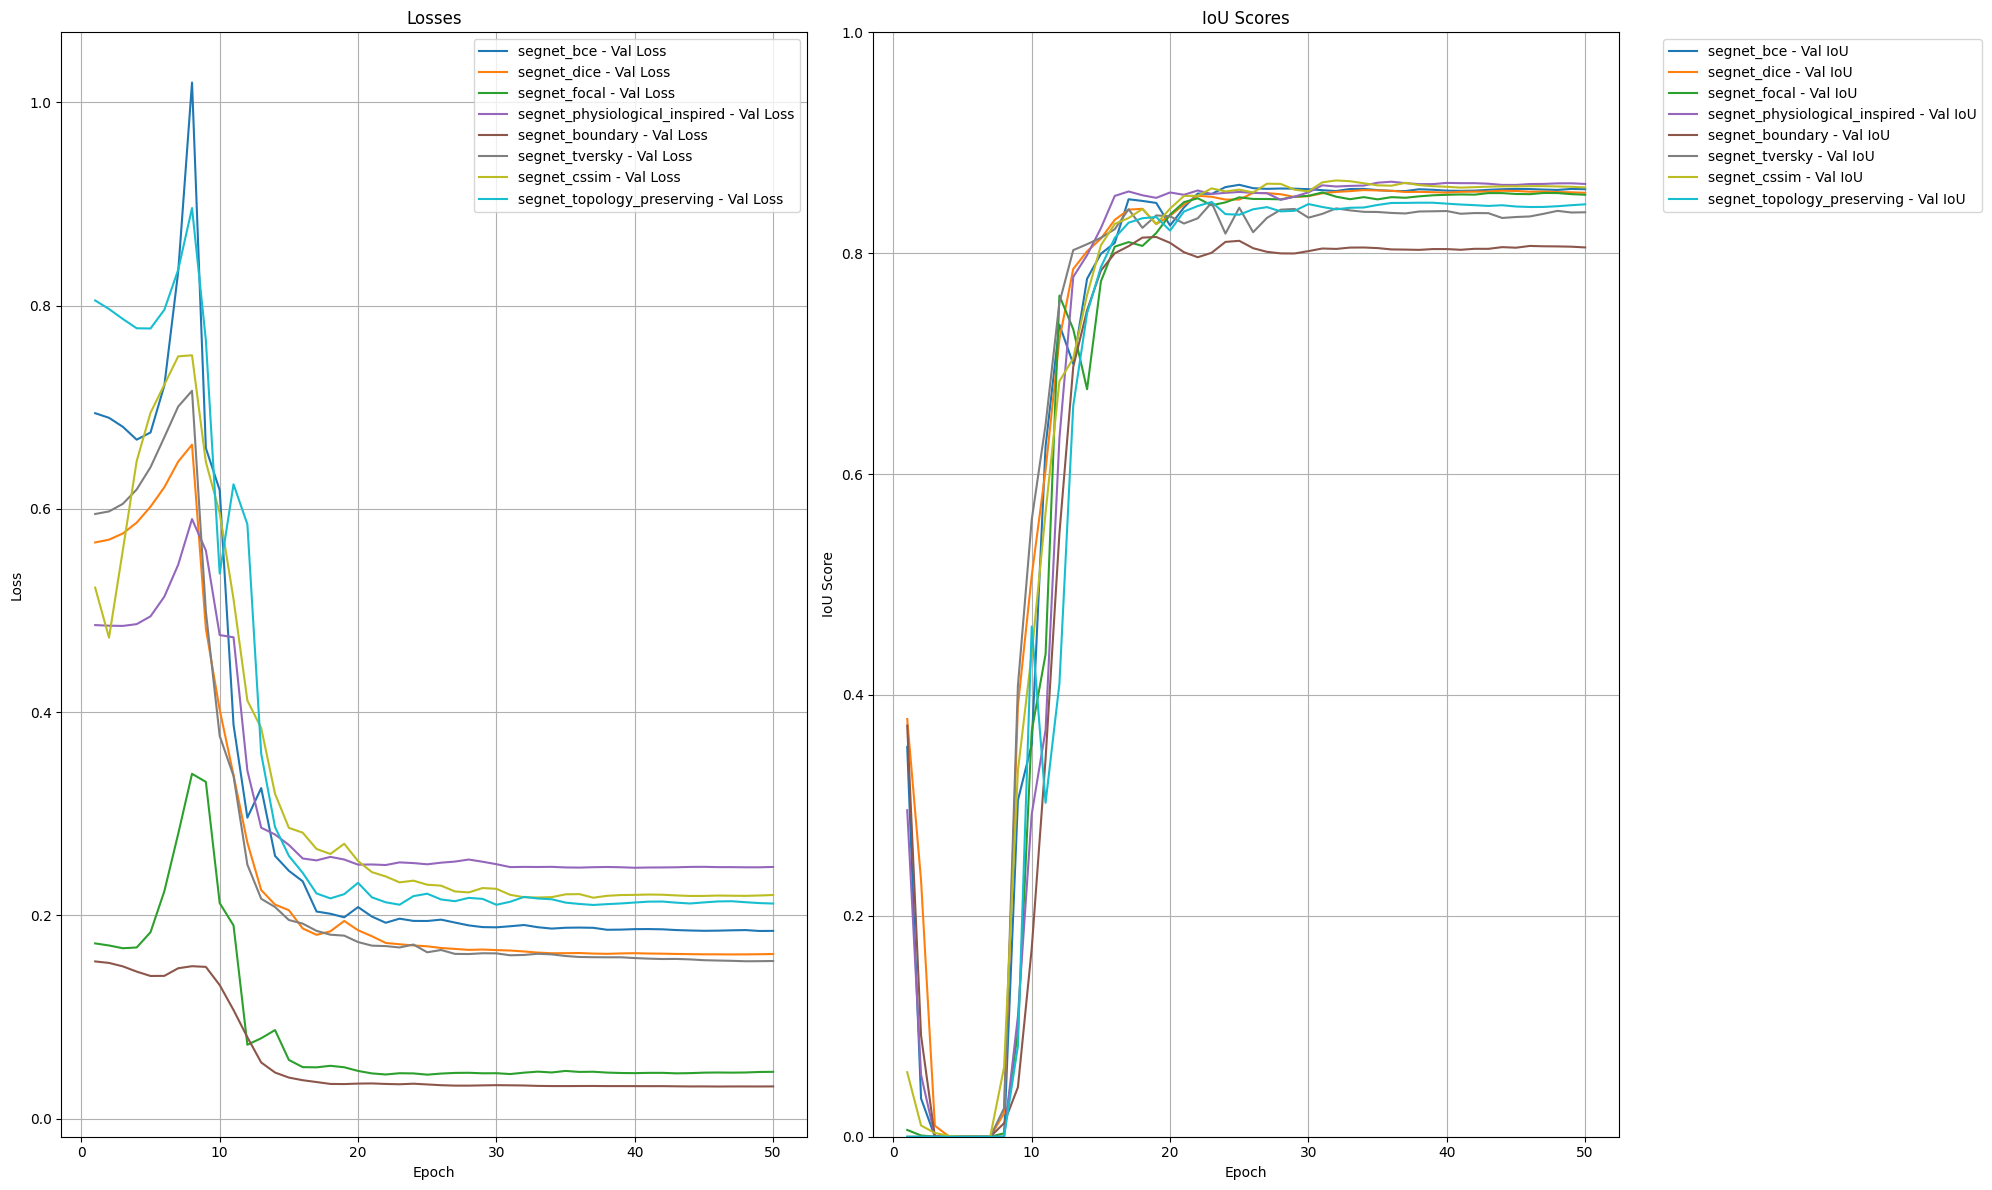

In [ ]:
# Список моделей для сравнения
segnet_models_to_compare = [
    (segnet_bce_model, segnet_bce_history, segnet_bce_model_name),
    (segnet_dice_model, segnet_dice_history, segnet_dice_model_name),
    (segnet_focal_model, segnet_focal_history, segnet_focal_model_name),
    (segnet_physiological_inspired_model, segnet_physiological_inspired_history, segnet_physiological_inspired_model_name),
    (segnet_boundary_model, segnet_boundary_history, segnet_boundary_model_name),
    (segnet_tversky_model, segnet_tversky_history, segnet_tversky_model_name),
    (segnet_cssim_model, segnet_cssim_history, segnet_cssim_model_name),
    (segnet_topology_preserving_model, segnet_topology_preserving_history, segnet_topology_preserving_model_name)
]

plot_metrics_full(segnet_models_to_compare)
plt.show();

*   При каком лоссе модель сходится быстрее?  
Модель SegNet c Boundary Loss сходится быстрее остальных моделей SegNet.  
Возможно, потому что модель с ранних эпох начинает образать внимание самые важные пиксели (границы),  
учитывая структуру построения такого типа лосса. 
*   При каком лоссе модель выдает наилучшую метрику?  
Модель SegNet c CSSIM Loss выдает наилучшую метрику среди моделей SegNet.     
CSSIM имеет высокий финальный IoU за счет структурного сходства.  
Модель с CSSIM Loss выделяет более гладкие маски, за счет штрафов за разрывы в предсказанных масках.

# Задание: Новая модель!

## Модель U-Net [2 балла]

[**U-Net**](https://arxiv.org/abs/1505.04597) — это архитектура нейронной сети, которая получает изображение и выводит его. Первоначально он был задуман для семантической сегментации (как мы ее будем использовать), но он настолько успешен, что с тех пор используется в других контекстах. Получая на вход медицинское изображение, он выведет изображение в оттенках серого, где интенсивность каждого пикселя зависит от вероятности того, что этот пиксель принадлежит интересующей нас области.


У нас в архитектуре все так же существует энкодер и декодер, как в **SegNet**, но отличительной особеностью данной модели являются *skip-conenctions*, соединяющие части декодера и энкодера. То есть для того чтобы передать на вход декодера тензор, мы конкатенируем симметричный выход с энкодера и выход предыдущего слоя декодера.

* Ronneberger, Olaf, Philipp Fischer, and Thomas Brox. "[U-Net: Convolutional networks for biomedical image segmentation.](https://arxiv.org/pdf/1505.04597.pdf)" International Conference on Medical image computing and computer-assisted intervention. Springer, Cham, 2015.

В оригинальной статье авторы не использовали padding внутри модели (это видно по тому, что размеры карты признаков уменьшаются на 2 каждый раз при движении от слоя к слою). При этом размеры входных изображений авторы единоразово увеличили при помощи mirror padding.

В этом домашнем задании вы можете применить альтернативный подход - сохранять размеры карт признаков при помощью padding = 1 во внутренних слоях.  

In [82]:
import torch.nn.functional as F
import torch.nn as nn

Для реализации UNet вы можете написать классы блоков энкодера и декодера отдельно, как мы сделали при реализации SegNet.

In [ ]:
class EncoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels, depth, kernel_size=3, padding=1):
        super(EncoderBlock, self).__init__()
        self.layers = nn.ModuleList()
    
        self.layers.append(
            nn.Conv2d(
                in_channels=in_channels,
                out_channels=out_channels,
                kernel_size=kernel_size,
                padding=padding
            )
        )
        self.layers.append(nn.BatchNorm2d(out_channels))
        self.layers.append(nn.ReLU(inplace=True))

        for i in range(depth-1):
            self.layers.append(
                nn.Conv2d(
                    in_channels=out_channels,
                    out_channels=out_channels,
                    kernel_size=kernel_size,
                    padding=padding
                )
            )
            self.layers.append(nn.BatchNorm2d(out_channels))
            self.layers.append(nn.ReLU(inplace=True))

        self.maxpooling = nn.MaxPool2d(
            kernel_size=2, stride=2
            )


    def forward(self, x):
        for layer in self.layers:
            x = layer(x)

        skip_connection = x

        x = self.maxpooling(x)
        return x, skip_connection


class BottleneckBlock(nn.Module):
    def __init__(self, in_channels, out_channels, depth=2, kernel_size=3, padding=1):
        super(BottleneckBlock, self).__init__()
        self.layers = nn.ModuleList()

        self.layers.append(
            nn.Conv2d(
                in_channels=in_channels, 
                out_channels=out_channels, 
                kernel_size=kernel_size, 
                padding=padding
            )
        )
        self.layers.append(nn.BatchNorm2d(out_channels))
        self.layers.append(nn.ReLU(inplace=True))

        for i in range(depth - 1):
            self.layers.append(
                nn.Conv2d(in_channels=out_channels,
                          out_channels=out_channels,
                          kernel_size=kernel_size,
                          padding=padding
                )
            )
            self.layers.append(nn.BatchNorm2d(out_channels))
            self.layers.append(nn.ReLU(inplace=True))

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
    

class DecoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels, skip_channels, depth, kernel_size=3, padding=1):
        super(DecoderBlock, self).__init__()
        self.layers = nn.ModuleList()
        self.upconv = nn.ConvTranspose2d(
            in_channels=in_channels, 
            out_channels=out_channels, 
            kernel_size=2, 
            stride=2
        )

        conv_in_channels = out_channels + skip_channels

        self.layers.append(
            nn.Conv2d(
                in_channels=conv_in_channels,
                out_channels=out_channels, 
                kernel_size=kernel_size, 
                padding=padding
            )
        )
        self.layers.append(nn.BatchNorm2d(out_channels))
        self.layers.append(nn.ReLU(inplace=True))

        for i in range(depth - 1):
            self.layers.append(
                nn.Conv2d(
                    in_channels=out_channels, 
                    out_channels=out_channels, 
                    kernel_size=kernel_size, 
                    padding=padding
                )
            )
            self.layers.append(nn.BatchNorm2d(out_channels))
            self.layers.append(nn.ReLU(inplace=True))

    def forward(self, x, skip_connection):
        x = self.upconv(x)
        x = torch.cat([skip_connection, x], dim=1)
        for layer in self.layers:
            x = layer(x)
        return x

In [84]:
class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, num_features=64):
        super(UNet, self).__init__()

        self.encoder1 = EncoderBlock(in_channels, num_features, depth=2)                                # 3->64
        self.encoder2 = EncoderBlock(num_features, num_features * 2, depth=2)                           # 64->128
        self.encoder3 = EncoderBlock(num_features * 2, num_features * 4, depth=2)                       # 128->256
        self.encoder4 = EncoderBlock(num_features * 4, num_features * 8, depth=2)                       # 256->512

        self.bottleneck = BottleneckBlock(num_features * 8, num_features * 8, depth=2)                  # 512->512

        self.decoder4 = DecoderBlock(num_features * 8, num_features * 8, num_features * 8, depth=2)     # 512->512, skip=512
        self.decoder3 = DecoderBlock(num_features * 8, num_features * 4, num_features * 4, depth=2)     # 512->256, skip=256
        self.decoder2 = DecoderBlock(num_features * 4, num_features * 2, num_features * 2, depth=2)     # 256->128, skip=128
        self.decoder1 = DecoderBlock(num_features * 2, num_features, num_features, depth=2)             # 128->64,  skip=64

        self.final_conv = nn.Conv2d(num_features, out_channels, kernel_size=1)                          # 64->1

    def forward(self, x):
        x, skip1 = self.encoder1(x)
        x, skip2 = self.encoder2(x)
        x, skip3 = self.encoder3(x)
        x, skip4 = self.encoder4(x)

        x = self.bottleneck(x)

        x = self.decoder4(x, skip4)
        x = self.decoder3(x, skip3)
        x = self.decoder2(x, skip2)
        x = self.decoder1(x, skip1)

        return self.final_conv(x)

In [85]:
unet_model = UNet().to(device)

## Обучите UNet

Задание: обучите UNet на всех трех лоссах: BCE, Dice, Focal и сравните результаты с SegNet:
*   Какая модель дает лучшие значения по метрике?
*   Какая модель дает лучшие значения по лоссам?
*   Какая модель обучается быстрее?
*   Сравните визуально результаты SegNet и UNet.

Напишите развернутый ответ на вопросы.



### UNet BCE loss

Best Validation Loss:   0.2421 (Epoch 22)
Best Validation IoU:    0.8715 (Epoch 22)


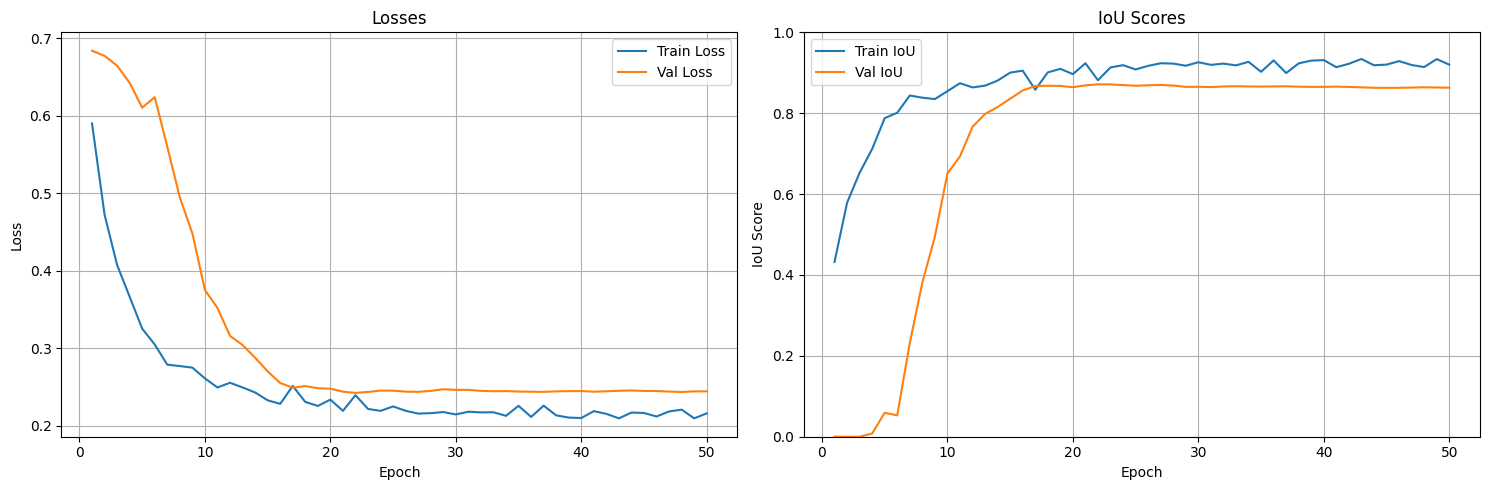


Epoch 50/50
Train Loss: 0.2158 | IoU: 0.9202
Val   Loss: 0.2442 | IoU: 0.8630

Best Validation IoU: 0.8715 on epoch 22


In [86]:
torch.cuda.empty_cache()

num_epochs = 50
criterion_name = 'bce'

model = UNet(in_channels=3, out_channels=1, num_features=64).to(device)
criterion = nn.BCEWithLogitsLoss(reduction='mean')
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
# optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
# scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

unet_bce_model, unet_bce_history, unet_bce_model_name = train_model(
    model=model, 
    loaders=loaders, 
    criterion=criterion, 
    optimizer=optimizer, 
    num_epochs=num_epochs,
    criterion_name=criterion_name,
    scheduler=scheduler
)

In [87]:
torch.cuda.empty_cache()

model, model_name = unet_bce_model, unet_bce_model_name
checkpoint_path = f'models/best_{model_name}.pth'

test(
    model=model,
    dataloader=loaders['test'],
    criterion=criterion,
    checkpoint_path=checkpoint_path
)

Validation:   0%|          | 0/50 [00:00<?, ?it/s]

Test Loss: 0.2488 | IoU: 0.8566


### UNet Dice loss

Best Validation Loss:   0.2177 (Epoch 49)
Best Validation IoU:    0.8582 (Epoch 49)


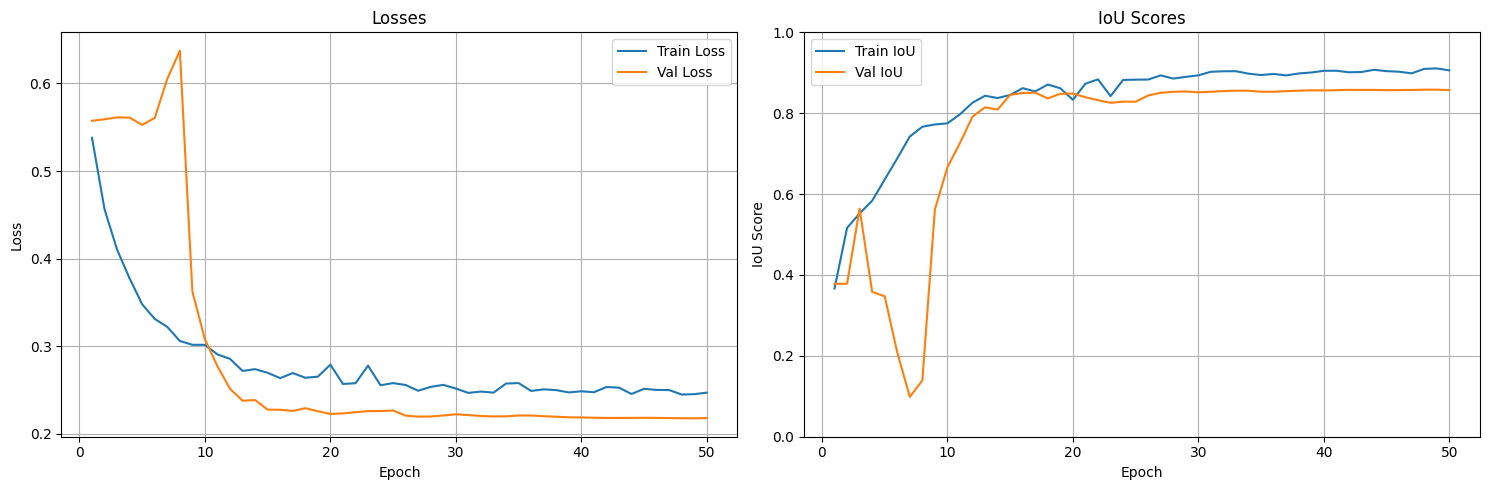


Epoch 50/50
Train Loss: 0.2471 | IoU: 0.9060
Val   Loss: 0.2181 | IoU: 0.8572

Best Validation IoU: 0.8582 on epoch 49


In [88]:
torch.cuda.empty_cache()

num_epochs = 50
criterion_name = 'dice'

model = UNet(in_channels=3, out_channels=1, num_features=64).to(device)
criterion = DiceLoss(mode='binary')
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
# optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
# scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

unet_dice_model, unet_dice_history, unet_dice_model_name = train_model(
    model=model, 
    loaders=loaders, 
    criterion=criterion, 
    optimizer=optimizer, 
    num_epochs=num_epochs,
    criterion_name=criterion_name,
    scheduler=scheduler
)

In [89]:
torch.cuda.empty_cache()

model, model_name = unet_dice_model, unet_dice_model_name
checkpoint_path = f'models/best_{model_name}.pth'

test(
    model=model,
    dataloader=loaders['test'],
    criterion=criterion,
    checkpoint_path=checkpoint_path
)

Validation:   0%|          | 0/50 [00:00<?, ?it/s]

Test Loss: 0.3415 | IoU: 0.8221


### UNet Focal loss

In [90]:
def focal_loss(y_pred, y_real, gamma=2):
    y_pred_prob = torch.sigmoid(y_pred)
    p_t = y_pred_prob * y_real + (1 - y_pred_prob) * (1 - y_real)
    bce = F.binary_cross_entropy_with_logits(y_pred, y_real.float(), reduction='none')
    focal_weight = (1 - p_t) ** gamma
    loss = focal_weight * bce
    
    return loss.mean()

Best Validation Loss:   0.0384 (Epoch 28)
Best Validation IoU:    0.8710 (Epoch 30)


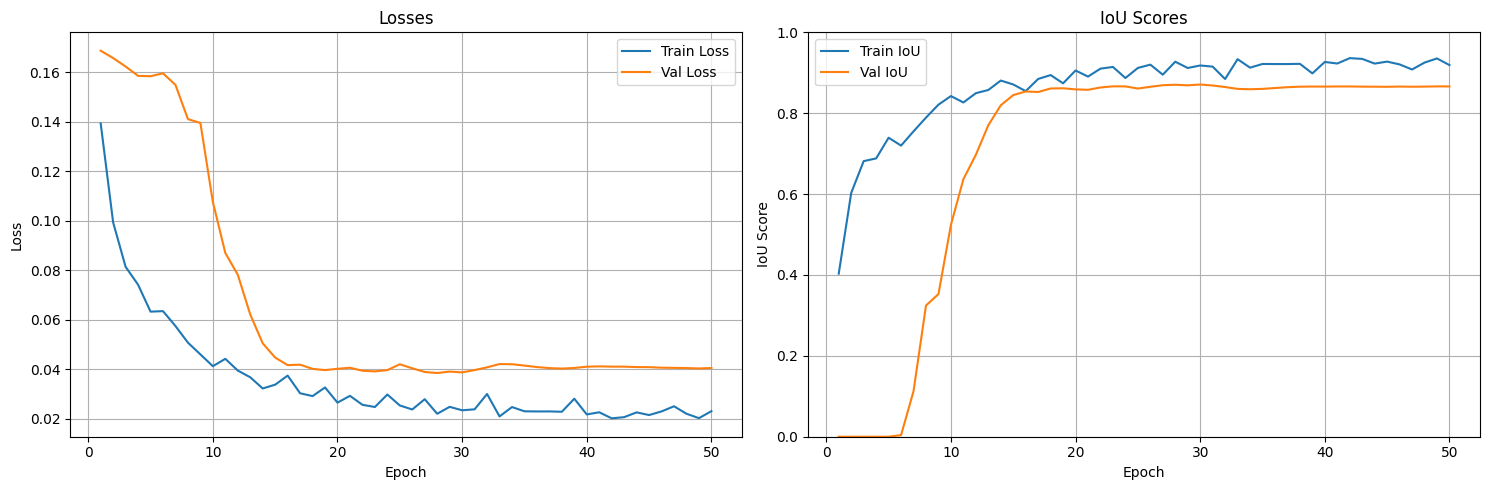


Epoch 50/50
Train Loss: 0.0230 | IoU: 0.9190
Val   Loss: 0.0404 | IoU: 0.8662

Best Validation IoU: 0.8710 on epoch 30


In [91]:
torch.cuda.empty_cache()

num_epochs = 50
criterion_name = 'focal'

model = UNet(in_channels=3, out_channels=1, num_features=64).to(device)
criterion = focal_loss
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
# optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
# scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

unet_focal_model, unet_focal_history, unet_focal_model_name = train_model(
    model=model, 
    loaders=loaders, 
    criterion=criterion, 
    optimizer=optimizer, 
    num_epochs=num_epochs,
    criterion_name=criterion_name,
    scheduler=scheduler
)

In [92]:
torch.cuda.empty_cache()

model, model_name = unet_focal_model, unet_focal_model_name
checkpoint_path = f'models/best_{model_name}.pth'

test(
    model=model,
    dataloader=loaders['test'],
    criterion=criterion,
    checkpoint_path=checkpoint_path
)

Validation:   0%|          | 0/50 [00:00<?, ?it/s]

Test Loss: 0.0462 | IoU: 0.8184


### UNet Physiological inspired loss

Best Validation Loss:   0.2623 (Epoch 21)
Best Validation IoU:    0.8617 (Epoch 50)


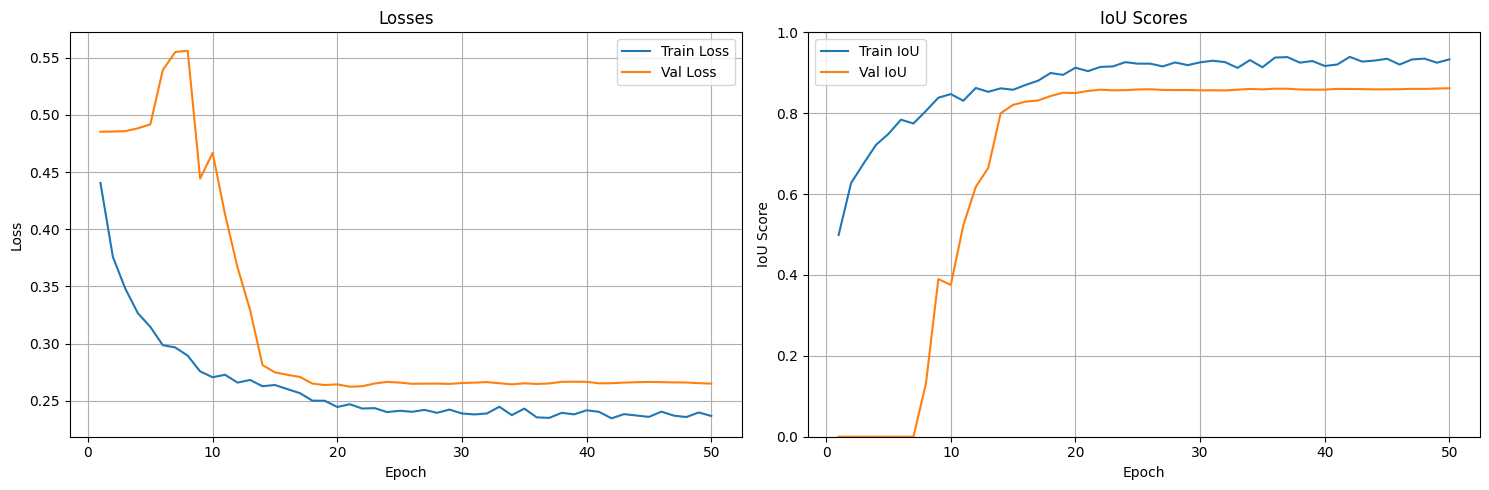


Epoch 50/50
Train Loss: 0.2367 | IoU: 0.9333
Val   Loss: 0.2651 | IoU: 0.8617

Best Validation IoU: 0.8617 on epoch 50


In [93]:
torch.cuda.empty_cache()

num_epochs = 50
criterion_name = 'physiological_inspired'

model = UNet(in_channels=3, out_channels=1, num_features=64).to(device)
criterion = physiological_inspired_loss
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
# optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
# scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

unet_physiological_inspired_model, unet_physiological_inspired_history, unet_physiological_inspired_model_name = train_model(
    model=model, 
    loaders=loaders, 
    criterion=criterion, 
    optimizer=optimizer, 
    num_epochs=num_epochs,
    criterion_name=criterion_name,
    scheduler=scheduler
)

In [94]:
torch.cuda.empty_cache()

model, model_name = unet_physiological_inspired_model, unet_physiological_inspired_model_name
checkpoint_path = f'models/best_{model_name}.pth'

test(
    model=model,
    dataloader=loaders['test'],
    criterion=criterion,
    checkpoint_path=checkpoint_path
)

Validation:   0%|          | 0/50 [00:00<?, ?it/s]

Test Loss: 0.2671 | IoU: 0.8448


### UNet Boundary loss

Best Validation Loss:   0.0381 (Epoch 18)
Best Validation IoU:    0.7614 (Epoch 19)


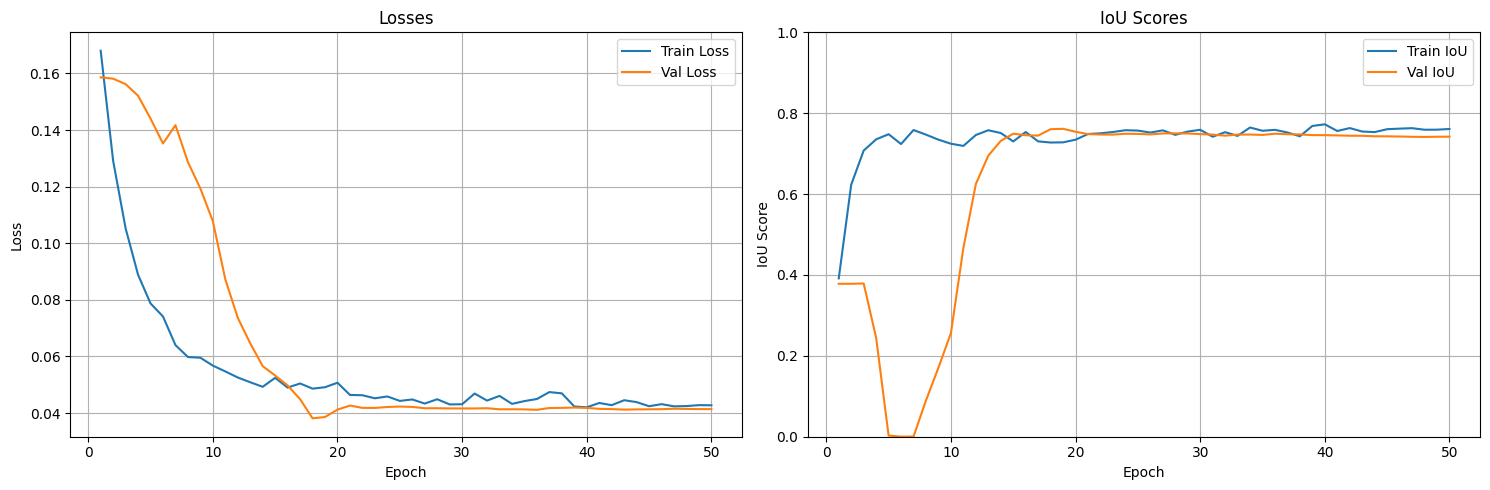


Epoch 50/50
Train Loss: 0.0428 | IoU: 0.7610
Val   Loss: 0.0414 | IoU: 0.7420

Best Validation IoU: 0.7614 on epoch 19


In [95]:
torch.cuda.empty_cache()

num_epochs = 50
criterion_name = 'boundary'

model = UNet(in_channels=3, out_channels=1, num_features=64).to(device)
criterion = boundary_loss
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
# optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
# scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

unet_boundary_model, unet_boundary_history, unet_boundary_model_name = train_model(
    model=model, 
    loaders=loaders, 
    criterion=criterion, 
    optimizer=optimizer, 
    num_epochs=num_epochs,
    criterion_name=criterion_name,
    scheduler=scheduler
)

In [96]:
torch.cuda.empty_cache()

model, model_name = unet_boundary_model, unet_boundary_model_name
checkpoint_path = f'models/best_{model_name}.pth'

test(
    model=model,
    dataloader=loaders['test'],
    criterion=criterion,
    checkpoint_path=checkpoint_path
)

Validation:   0%|          | 0/50 [00:00<?, ?it/s]

Test Loss: 0.0584 | IoU: 0.7255


### UNet Tversky loss

Best Validation Loss:   0.2045 (Epoch 18)
Best Validation IoU:    0.8556 (Epoch 16)


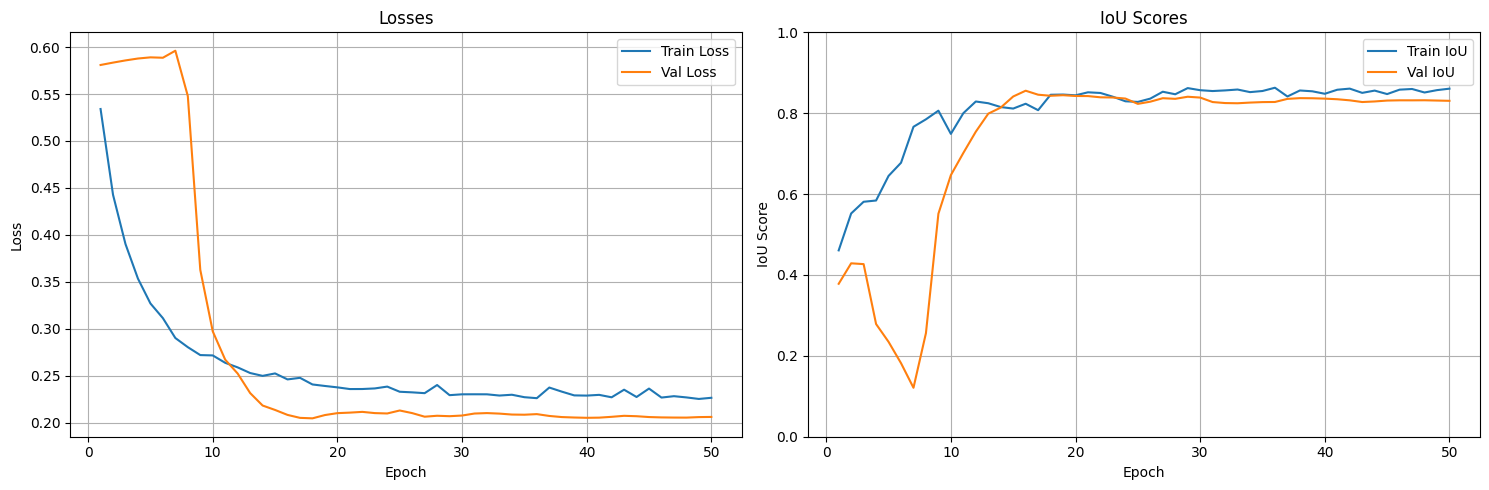


Epoch 50/50
Train Loss: 0.2264 | IoU: 0.8607
Val   Loss: 0.2060 | IoU: 0.8306

Best Validation IoU: 0.8556 on epoch 16


In [97]:
torch.cuda.empty_cache()

num_epochs = 50
criterion_name = 'tversky'

model = UNet(in_channels=3, out_channels=1, num_features=64).to(device)
criterion = tversky_loss
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
# optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
# scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

unet_tversky_model, unet_tversky_history, unet_tversky_model_name = train_model(
    model=model, 
    loaders=loaders, 
    criterion=criterion, 
    optimizer=optimizer, 
    num_epochs=num_epochs,
    criterion_name=criterion_name,
    scheduler=scheduler
)

In [98]:
torch.cuda.empty_cache()

model, model_name = unet_tversky_model, unet_tversky_model_name
checkpoint_path = f'models/best_{model_name}.pth'

test(
    model=model,
    dataloader=loaders['test'],
    criterion=criterion,
    checkpoint_path=checkpoint_path
)

Validation:   0%|          | 0/50 [00:00<?, ?it/s]

Test Loss: 0.2370 | IoU: 0.8301


### UNet Сssim loss

Best Validation Loss:   0.2655 (Epoch 32)
Best Validation IoU:    0.8580 (Epoch 33)


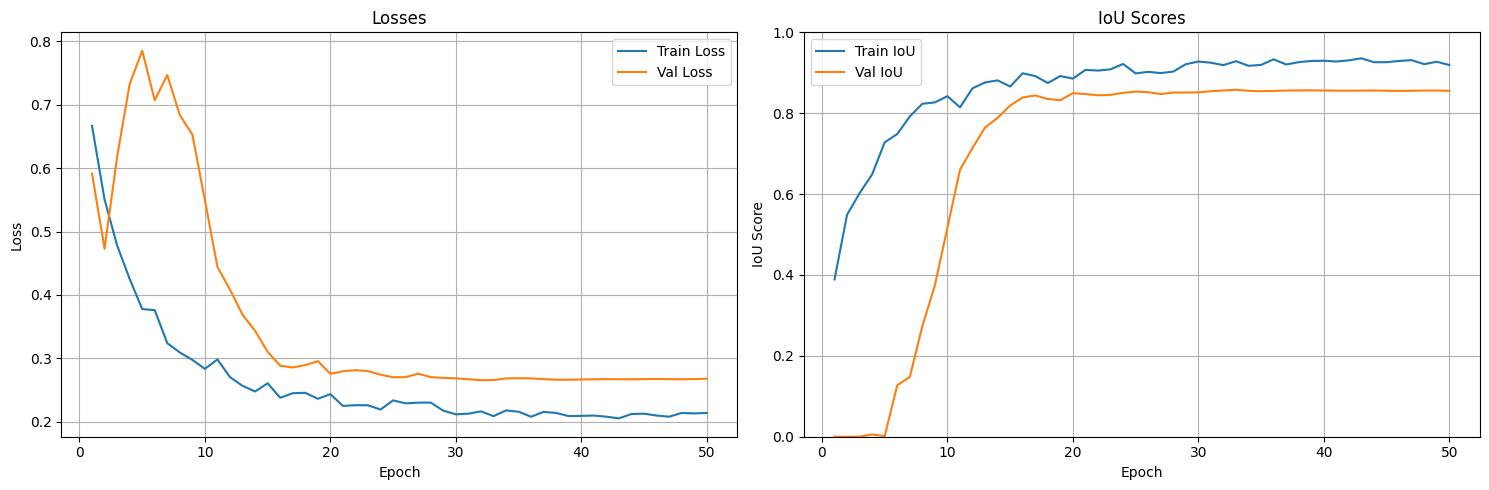


Epoch 50/50
Train Loss: 0.2138 | IoU: 0.9193
Val   Loss: 0.2677 | IoU: 0.8554

Best Validation IoU: 0.8580 on epoch 33


In [99]:
torch.cuda.empty_cache()

num_epochs = 50
criterion_name = 'cssim'

model = UNet(in_channels=3, out_channels=1, num_features=64).to(device)
criterion = cssim_loss
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
# optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
# scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

unet_cssim_model, unet_cssim_history, unet_cssim_model_name = train_model(
    model=model, 
    loaders=loaders, 
    criterion=criterion, 
    optimizer=optimizer, 
    num_epochs=num_epochs,
    criterion_name=criterion_name,
    scheduler=scheduler
)

In [100]:
torch.cuda.empty_cache()

model, model_name = unet_cssim_model, unet_cssim_model_name
checkpoint_path = f'models/best_{model_name}.pth'

test(
    model=model,
    dataloader=loaders['test'],
    criterion=criterion,
    checkpoint_path=checkpoint_path
)

Validation:   0%|          | 0/50 [00:00<?, ?it/s]

Test Loss: 0.2684 | IoU: 0.8264


### UNet topology_preserving loss

Best Validation Loss:   0.2593 (Epoch 37)
Best Validation IoU:    0.8665 (Epoch 32)


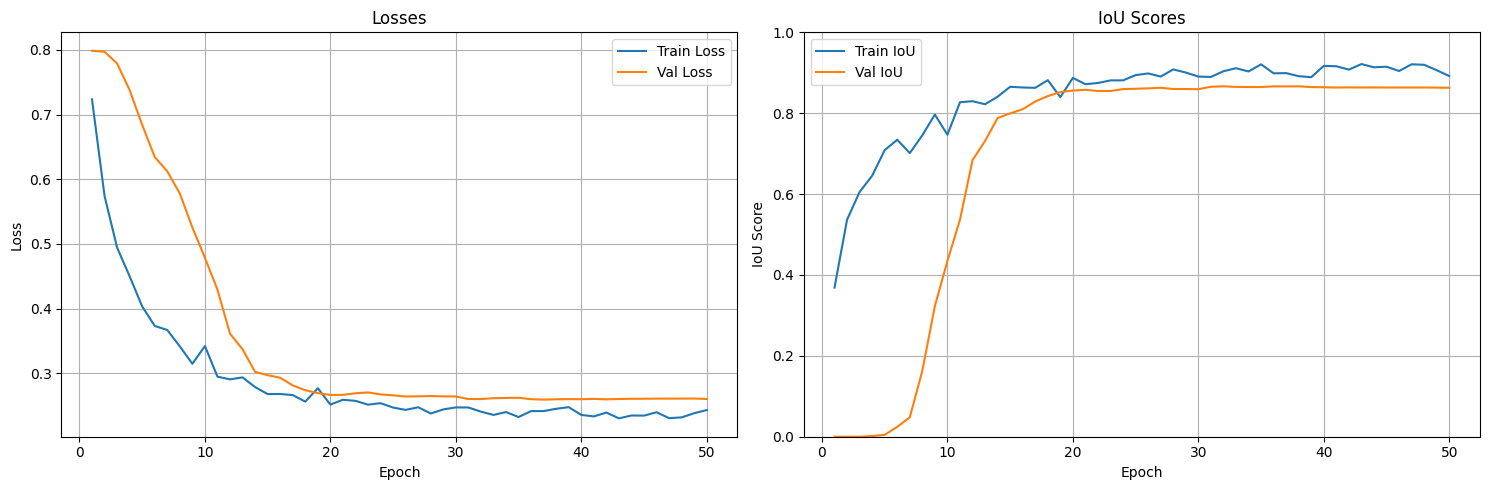


Epoch 50/50
Train Loss: 0.2433 | IoU: 0.8920
Val   Loss: 0.2604 | IoU: 0.8629

Best Validation IoU: 0.8665 on epoch 32


In [101]:
torch.cuda.empty_cache()

num_epochs = 50
criterion_name = 'topology_preserving'

model = UNet(in_channels=3, out_channels=1, num_features=64).to(device)
criterion = topology_preserving_loss
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
# optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
# scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

unet_topology_preserving_model, unet_topology_preserving_history, unet_topology_preserving_model_name = train_model(
    model=model, 
    loaders=loaders, 
    criterion=criterion, 
    optimizer=optimizer, 
    num_epochs=num_epochs,
    criterion_name=criterion_name,
    scheduler=scheduler
)

In [102]:
torch.cuda.empty_cache()

model, model_name = unet_topology_preserving_model, unet_topology_preserving_model_name
checkpoint_path = f'models/best_{model_name}.pth'

test(
    model=model,
    dataloader=loaders['test'],
    criterion=criterion,
    checkpoint_path=checkpoint_path
)

Validation:   0%|          | 0/50 [00:00<?, ?it/s]

Test Loss: 0.2882 | IoU: 0.8298


### Сравнение моделей UNet с различными функциями потерь

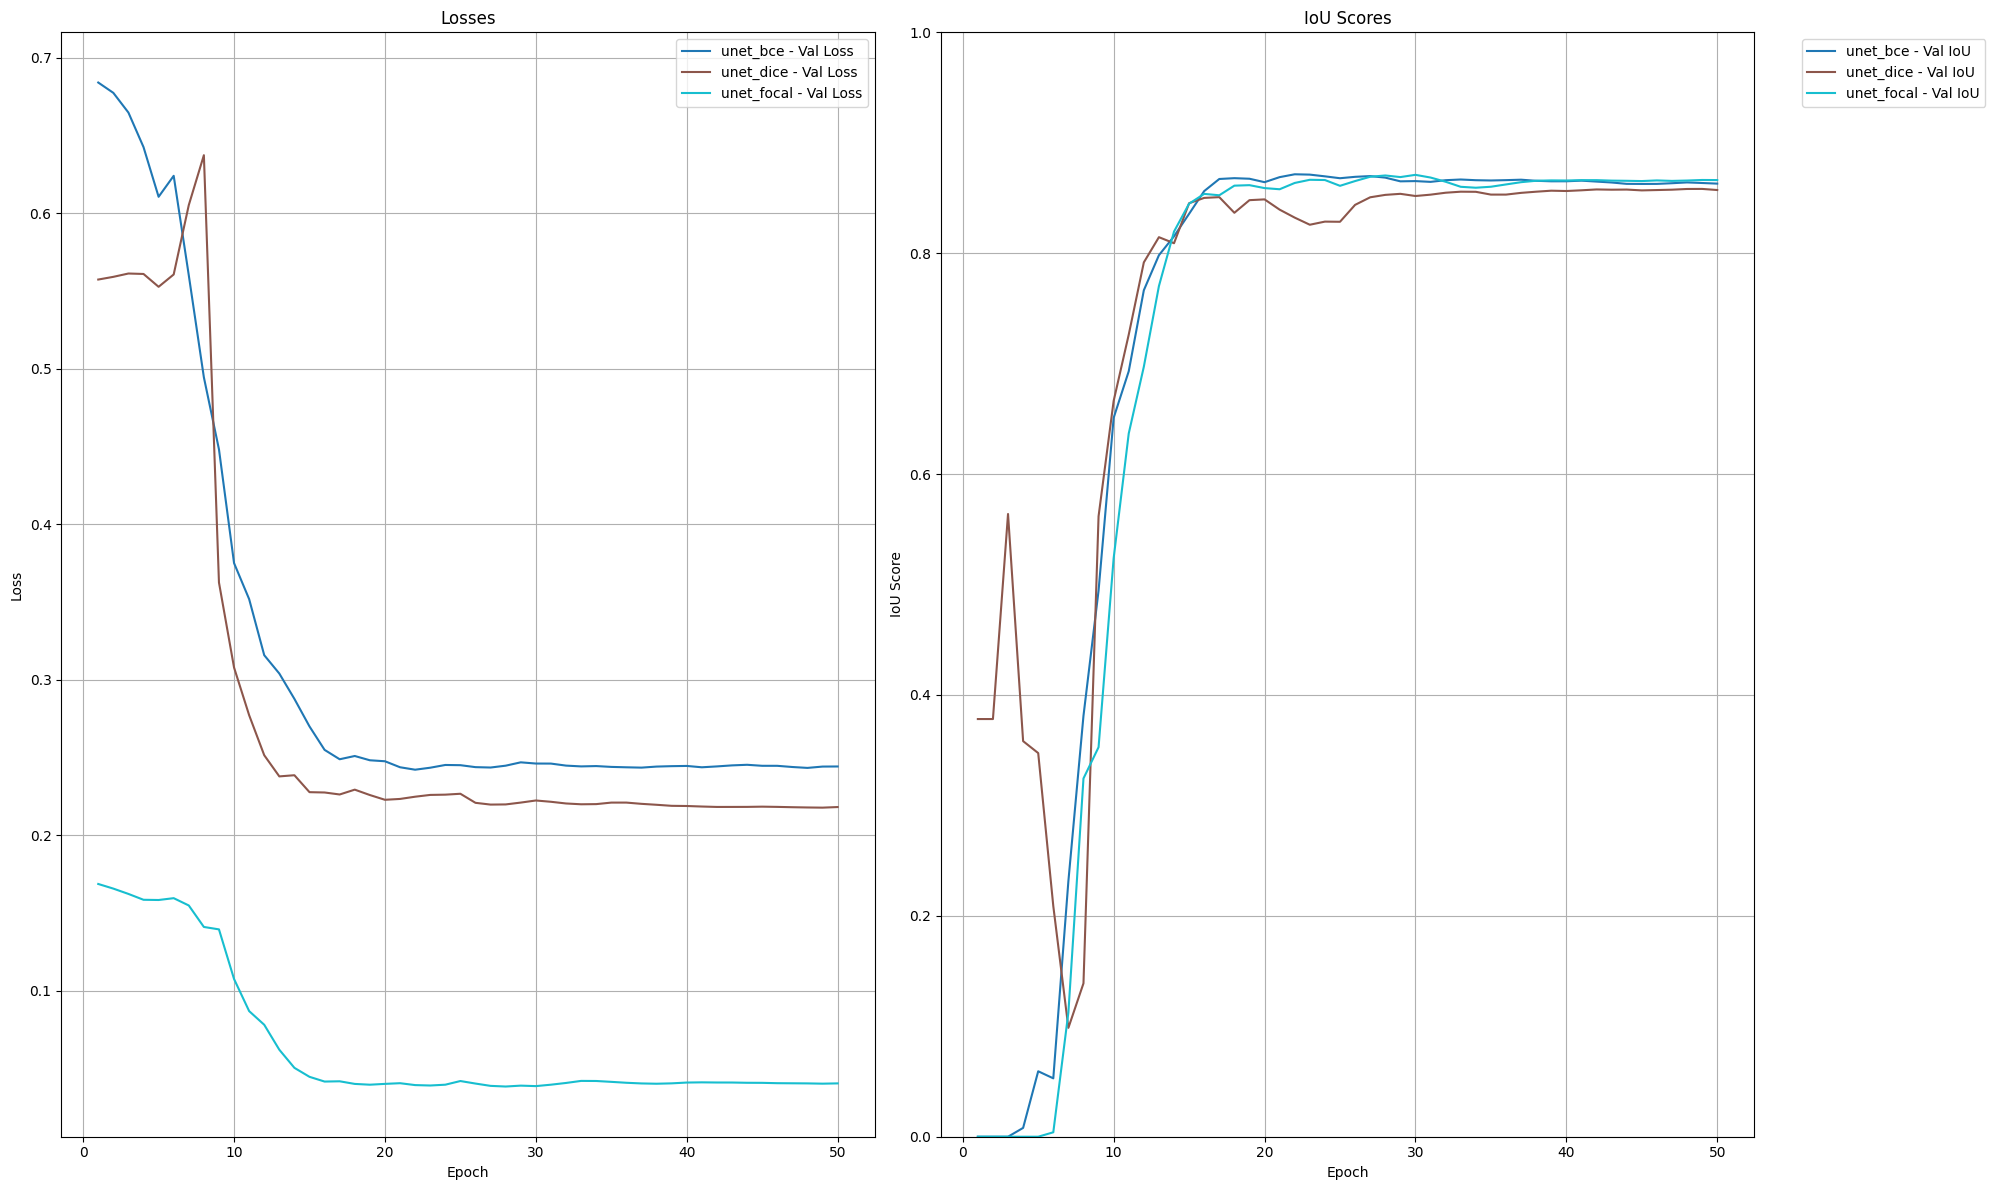

In [103]:
# Список моделей для сравнения (по заданию)
unet_models_to_compare_light = [
    (unet_bce_model, unet_bce_history, unet_bce_model_name),
    (unet_dice_model, unet_dice_history, unet_dice_model_name),
    (unet_focal_model, unet_focal_history, unet_focal_model_name)
]

plot_metrics_full(unet_models_to_compare_light)
plt.show();

### Ответы на вопросы

см. Финальная таблица сравнения моделей (в конце ноутбука)

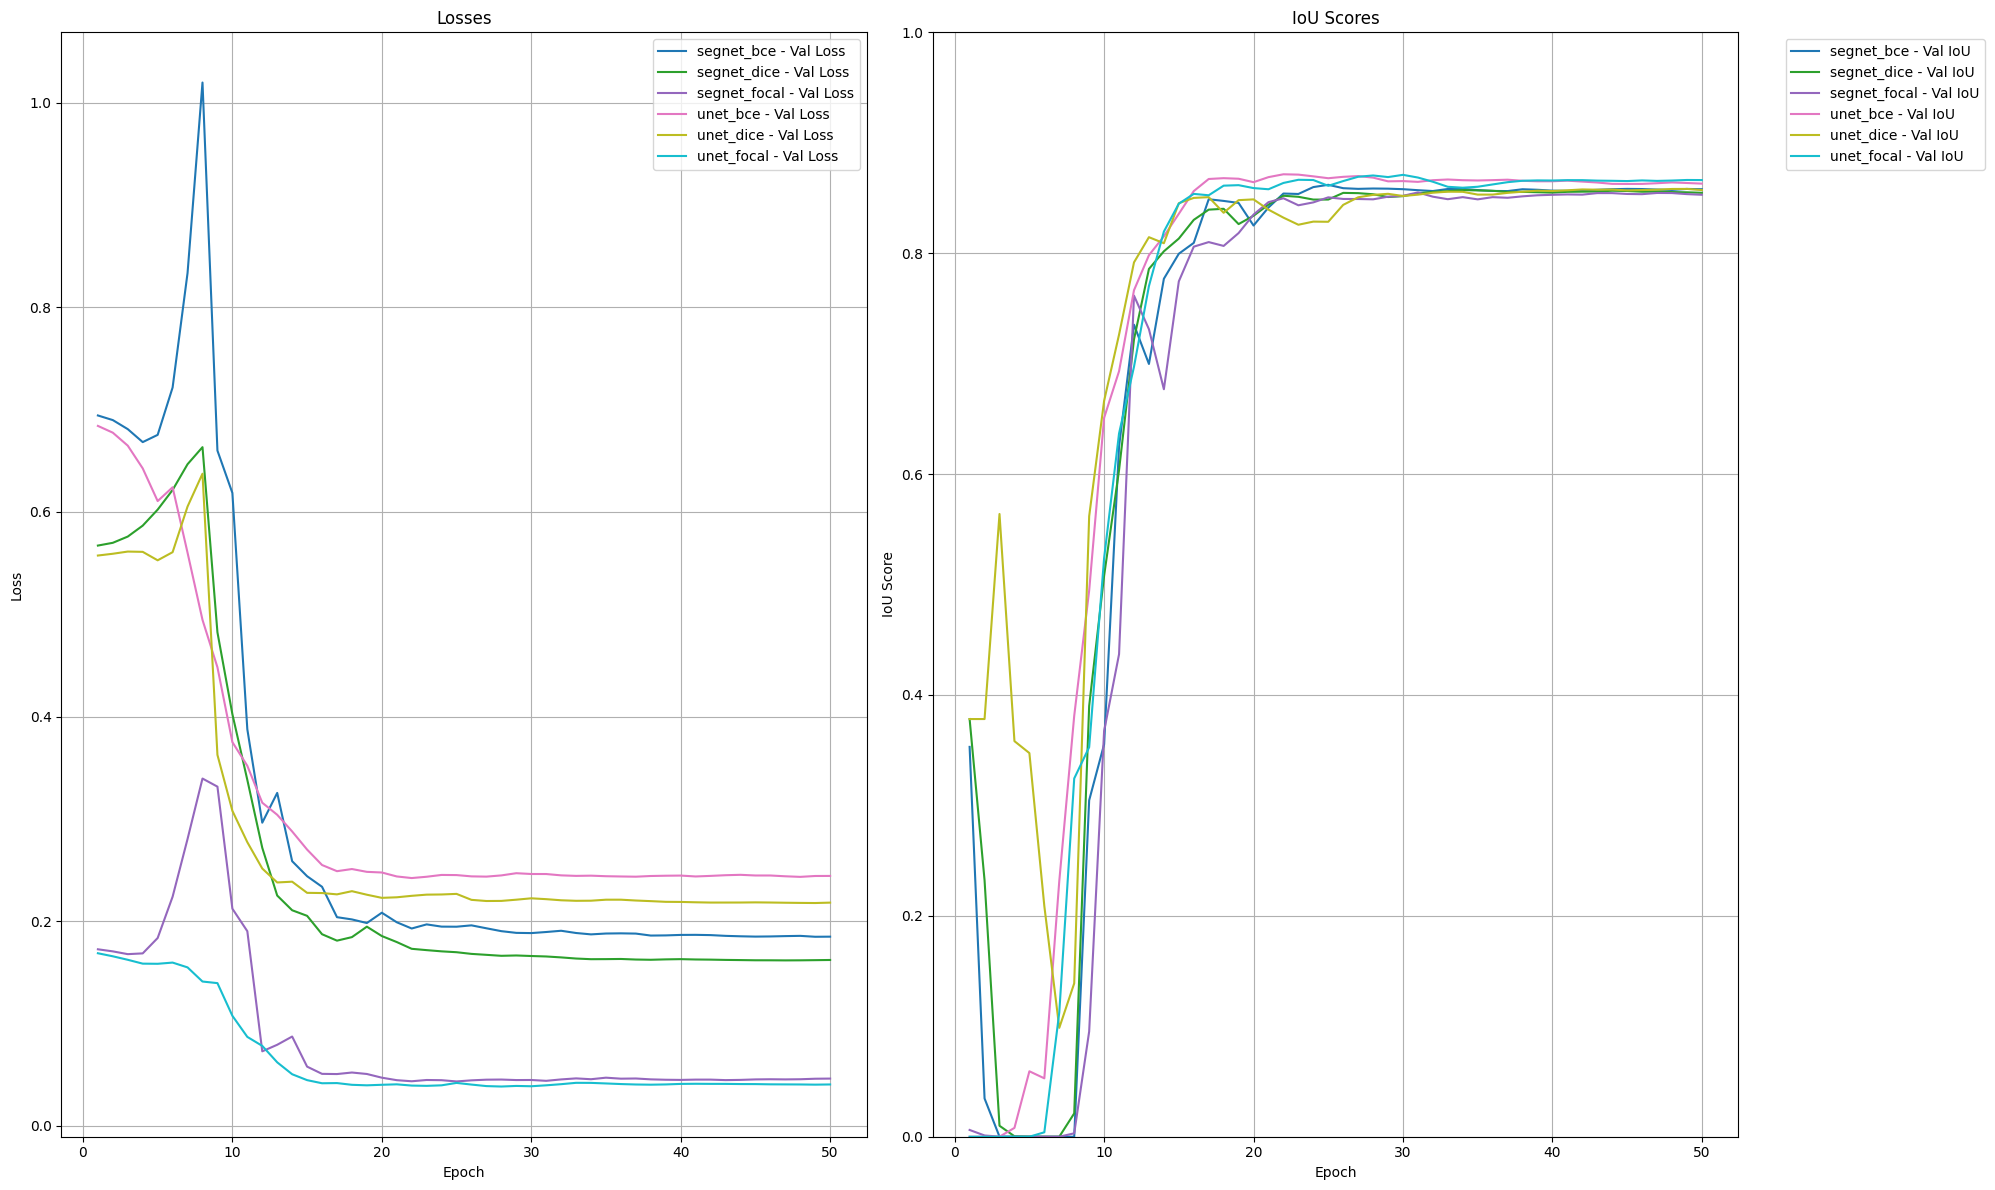

In [104]:
# Визуальное сравнение моделей SegNet и Unet

all_models_to_compare_light = segnet_models_to_compare_light + unet_models_to_compare_light

plot_metrics_full(all_models_to_compare_light)
plt.show();

* Какая модель дает лучшие значения по метрике?  
Модель UNet c BCE Loss дает лучшие значения по метрике среди моделей UNet.  
Так как skip-connection в UNet уже хорошо передает пространсвенную информацию,  
а простая BCE Loss хорошо уживается с UNet. Операции в Dice и Focal, возможно, слишком избыточны.
* Какая модель дает лучшие значения по лоссам?  
Модель UNet c Focal Loss дает лучшие значения по лоссам среди моделей UNet.  
Возможно что просто другой масштаб.
* Какая модель обучается быстрее?  
Модель UNet c BCE Loss обучается быстрее остальных моделей UNet.  
BCE Loss простая модель, не требующая сложных вычислений.
* Сравните визуально результаты SegNet и UNet.  
SegNet имеет меньше параметров и обучается быстрее,  
UNet требует больше времени на обучение из-за конкатенаций (skip-connections).  
UNet быстрее выходит на хорошее качество метрики IoU (больше информации об объектах из-за skip-connections),  
и в большинсве случаев использования различных лоссов значение метрики выше у UNet моделей.

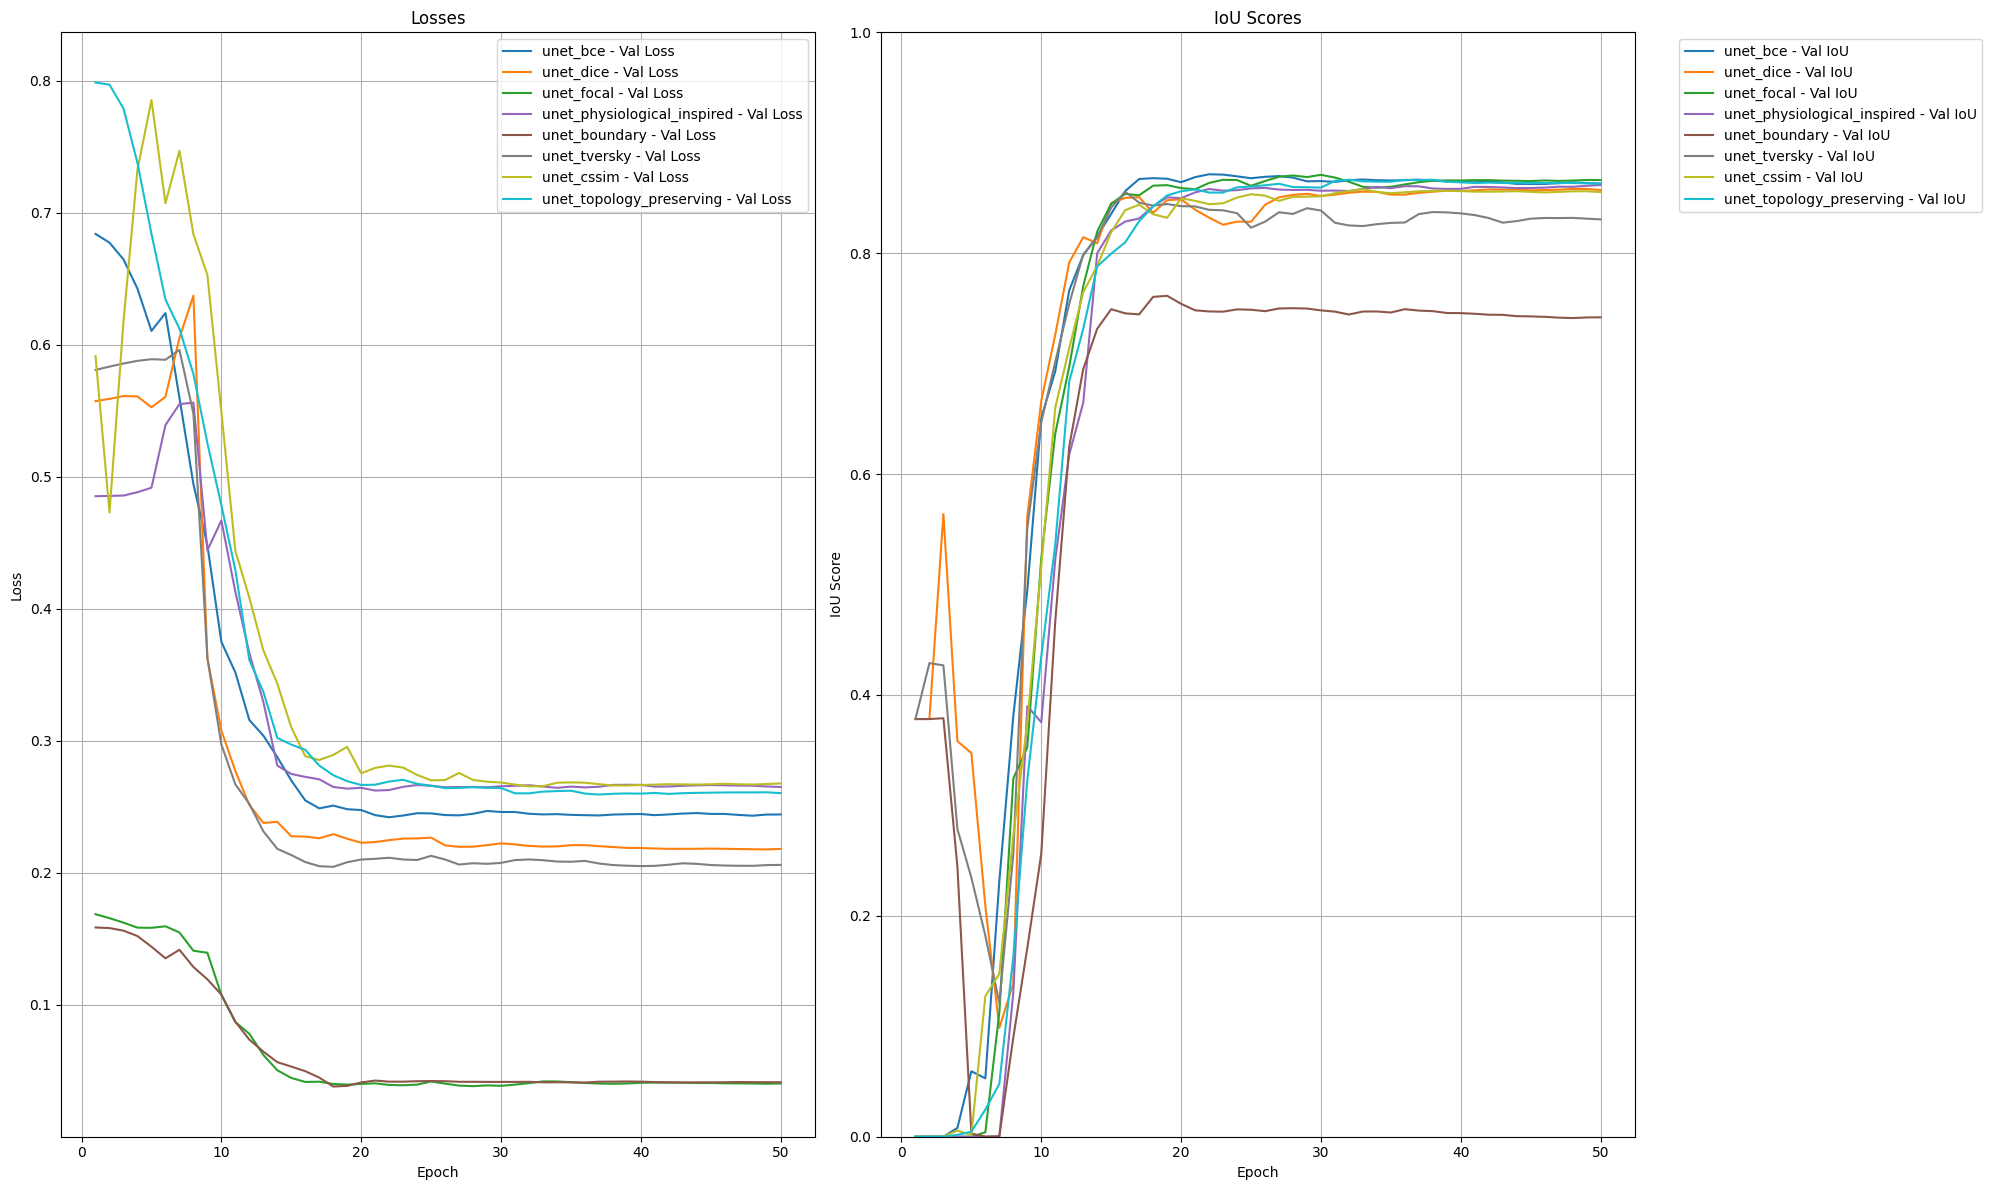

In [ ]:
# Список моделей для сравнения
unet_models_to_compare = [
    (unet_bce_model, unet_bce_history, unet_bce_model_name),
    (unet_dice_model, unet_dice_history, unet_dice_model_name),
    (unet_focal_model, unet_focal_history, unet_focal_model_name),
    (unet_physiological_inspired_model, unet_physiological_inspired_history, unet_physiological_inspired_model_name),
    (unet_boundary_model, unet_boundary_history, unet_boundary_model_name),
    (unet_tversky_model, unet_tversky_history, unet_tversky_model_name),
    (unet_cssim_model, unet_cssim_history, unet_cssim_model_name),
    (unet_topology_preserving_model, unet_topology_preserving_history, unet_topology_preserving_model_name)
]

plot_metrics_full(unet_models_to_compare)
plt.show();

* Какая модель дает лучшие значения по метрике?  
Модель UNet c BCE Loss дает лучшие значения по метрике среди моделей UNet.  
Просто хорошая связка UNet и BCE Loss.
* Какая модель дает лучшие значения по лоссам?  
Модель UNet c Boundary/Focal Loss дает лучшие значения по лоссам среди моделей UNet.
* Какая модель обучается быстрее?  
Модель UNet c Tversky Loss обучается быстрее остальных моделей UNet.  
Tversky Loss с beta=0.7 сильнее штрафует FN (пропуск пикселя),  
skip-connection в UNet делает больший акциент именно на пропуски,  
тем самым модель быстрее учится не пропускать пиксели.

# Финальная таблица сравнения моделей

In [106]:
import pandas as pd

all_models_to_compare = unet_models_to_compare + segnet_models_to_compare

results = []

for model, history, name in all_models_to_compare:
    best_val_loss = min(history['val_loss'])
    best_val_loss_epoch = history['val_loss'].index(best_val_loss) + 1
    
    best_val_iou = max(history['val_iou'])
    best_val_iou_epoch = history['val_iou'].index(best_val_iou) + 1
    
    best_train_loss = min(history['train_loss'])
    best_train_iou = max(history['train_iou'])
    

    parts = name.split('_')
    # Извлечение типа архитектуры модели
    model_type = parts[0].upper()
    # Извлечение названия функции потерь
    loss_name = '_'.join(parts[1:])
    
    results.append({
        'Model': model_type,
        'Loss': loss_name.upper(),
        'Full Name': name,
        'Best Val Loss': round(best_val_loss, 4),
        'Best Val IoU': round(best_val_iou, 4),
        'Best Train Loss': round(best_train_loss, 4),
        'Best Train IoU': round(best_train_iou, 4),
        'Best Val Loss Epoch': best_val_loss_epoch,
        'Best Val IoU Epoch': best_val_iou_epoch,
    })

df_results = pd.DataFrame(results)

# Сортировка по Best Val IoU
df_results = df_results.sort_values('Best Val IoU', ascending=False).reset_index(drop=True)

In [129]:
# df_results[df_results['Model']=='SEGNET'].sort_values('Best Val IoU Epoch', ascending=True).reset_index(drop=True)
# df_results[df_results['Model']=='SEGNET'].sort_values('Best Val IoU', ascending=False).reset_index(drop=True)

# df_results[df_results['Model']=='UNET'].sort_values('Best Val IoU', ascending=False).reset_index(drop=True)
df_results[df_results['Model']=='UNET'].sort_values('Best Val Loss', ascending=True).reset_index(drop=True)
# df_results[df_results['Model']=='UNET'].sort_values('Best Val IoU Epoch', ascending=True).reset_index(drop=True)


# df_results.sort_values('Best Val Loss', ascending=True).reset_index(drop=True)
# df_results.sort_values('Best Val IoU', ascending=False).reset_index(drop=True)
# df_results.sort_values('Best Val IoU Epoch', ascending=True).reset_index(drop=True)

,Model,Loss,Full Name,Best Val Loss,Best Val IoU,Best Train Loss,Best Train IoU,Best Val Loss Epoch,Best Val IoU Epoch
0,UNET,BOUNDARY,unet_boundary,0.0381,0.7614,0.0420,0.7725,18,19
1,UNET,FOCAL,unet_focal,0.0384,0.8710,0.0201,0.9362,28,30
2,UNET,TVERSKY,unet_tversky,0.2045,0.8556,0.2252,0.8630,18,16
3,UNET,DICE,unet_dice,0.2177,0.8582,0.2449,0.9108,49,49
4,UNET,BCE,unet_bce,0.2421,0.8715,0.2093,0.9341,22,22
5,UNET,TOPOLOGY_PRESERVING,unet_topology_preserving,0.2593,0.8665,0.2304,0.9215,37,32
6,UNET,PHYSIOLOGICAL_INSPIRED,unet_physiological_inspired,0.2623,0.8617,0.2347,0.9393,21,50
7,UNET,CSSIM,unet_cssim,0.2655,0.8580,0.2053,0.9358,32,33


In [116]:
# Общая таблица со всеми моедлями с сортировкой по Best Val IoU

df_results

,Model,Loss,Full Name,Best Val Loss,Best Val IoU,Best Train Loss,Best Train IoU,Best Val Loss Epoch,Best Val IoU Epoch
0,UNET,BCE,unet_bce,0.2421,0.8715,0.2093,0.9341,22,22
1,UNET,FOCAL,unet_focal,0.0384,0.8710,0.0201,0.9362,28,30
2,UNET,TOPOLOGY_PRESERVING,unet_topology_preserving,0.2593,0.8665,0.2304,0.9215,37,32
3,SEGNET,CSSIM,segnet_cssim,0.2175,0.8659,0.1423,0.9518,37,32
4,SEGNET,PHYSIOLOGICAL_INSPIRED,segnet_physiological_inspired,0.2469,0.8647,0.2032,0.9560,40,36
5,SEGNET,BCE,segnet_bce,0.1848,0.8619,0.0999,0.9525,49,25
6,UNET,PHYSIOLOGICAL_INSPIRED,unet_physiological_inspired,0.2623,0.8617,0.2347,0.9393,21,50
7,UNET,DICE,unet_dice,0.2177,0.8582,0.2449,0.9108,49,49
8,UNET,CSSIM,unet_cssim,0.2655,0.8580,0.2053,0.9358,32,33
9,SEGNET,DICE,segnet_dice,0.1617,0.8572,0.1569,0.9313,47,34


# Выводы

Модели UNet в целом показывают результаты лучше, нежели модели SegNet, но обучаются дольше (из-за skip-connections).  
UNet хорошо комбинируется с простой в вычислениях функцией потерь BCE,  
так как в структуре UNet за счет skip-connections уже передается достаточное  
для получения хорошего качества количество информации об объектах, а сложные оптимизаторы могут быть избыточны.  
Для моделей SegNet может быть недостаточно пространственной информации об объектах и  
применение сложных оптимизаторов может быть полезно.  
На начальных эпохах замечены скачки лосса и около нулевые значения метрики.  
Стабилизация обучения начинается примерно с 6-8 эпохи.  
До 6-8 эпохи модели делают случайные предсказания.  
А после уже происходит примерное выделение контуров и дальнейшее уточнение границ.